# 03 · Exploratory & Diagnostic Analysis

**Engagement question:** *where does the service network lose time, money and customer goodwill - and what is
associated with it?*

This notebook is the analytical core of the project. It moves from **what happened** (KPIs and trends) to
**where** (centres, technicians, service types, models) to **what is associated with it** (workload, parts,
skill, booking behaviour), and ends with the **bottlenecks** and simple **what-if** capacity estimates that feed
`docs/findings.md`, `docs/root_cause_analysis.md` and `docs/recommendations.md`.

**Ground rules**
* All numbers come from `data/cleaned/` via `src/analysis_metrics.py` (pure functions), so the documents can be
  regenerated and verified (`python -m src.analysis_metrics`).
* KPIs use the canonical project definitions (Revenue = Σ revenue; Cost = Σ(labour + parts); On-time = mean
  `on_time_flag`; Utilisation = Σ service hours / Σ available hours; etc.).
* Relationships are **associations**. Statistical tests are reported with **effect sizes**; with ~24k jobs almost
  everything is "significant", so the effect size is what tells us whether it matters. No result here is
  treated as proof of cause - each is a hypothesis for operational follow-up.
* Data is synthetic (modelled on an Ather-style EV two-wheeler network; not affiliated with Ather Energy).

In [1]:
# Locate the project root (folder containing src/ and data/) so the notebook runs from anywhere.
import os, sys
from pathlib import Path

_here = Path.cwd().resolve()
ROOT = next(p for p in [_here, *_here.parents] if (p / "src").is_dir() and (p / "data").is_dir())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\Vehicle_Service_Operations_Analytics


In [2]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src import analysis_metrics as am

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.3f}".format)

# ---- consistent chart style -------------------------------------------------
BLUE, ORANGE, AQUA, RED, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#c4c2bb", "#1f1f1f", "#6b6a66"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.labelcolor": INK, "axes.edgecolor": "#9a988f", "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e4df", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    print(f"saved reports/figures/{name}.png")

lakh = mticker.FuncFormatter(lambda x, _: f"₹{x / 1e5:,.0f}L")
pctfmt = mticker.PercentFormatter(1.0, decimals=0)

# ---- data -------------------------------------------------------------------
d = am.load_cleaned()
fs, fa, ftm, techs = d["fact_service"], d["fact_appointments"], d["fact_technician_month"], d["technicians"]
daily = am.daily_load(fs, techs)
fsl = am.attach_load(fs, daily)
lines = am.parts_lines(fs, d["part_usage"], d["parts"])
M = am.compute_all(d)
H = M["headline"]
NAMES = d["service_centers"].set_index("center_id")["center_name"].to_dict()
SHORT = {k: v.split(" - ")[0] if v.split(" - ")[0] not in ("Bengaluru",) else "Blr " + v.split(" - ")[1] for k, v in NAMES.items()}
print(f"{len(fs):,} work orders | {len(fa):,} appointments | {fs['service_date'].min():%d %b %Y} → {fs['service_date'].max():%d %b %Y}")

24,092 work orders | 26,769 appointments | 01 Jan 2025 → 30 Sep 2026


## 1. Headline KPIs (network, Jan 2025 - Sep 2026)

In [3]:
kpi = pd.DataFrame([
    ("Revenue", am.inr(H["revenue"])), ("Total cost (labour + parts)", am.inr(H["total_cost"])),
    ("Profit", am.inr(H["profit"])), ("Margin", am.pct(H["margin"])),
    ("Avg service cost / job", am.inr(H["avg_service_cost"])), ("Avg revenue / job", am.inr(H["avg_revenue_per_job"])),
    ("Work orders", f"{H['work_orders']:,}"), ("On-time %", am.pct(H["on_time_rate"])),
    ("Avg / median turnaround", f"{H['avg_turnaround_h']:.1f} h / {H['median_turnaround_h']:.2f} h"),
    ("Avg wait before work starts", f"{H['avg_wait_h']:.2f} h"),
    ("Technician utilisation", am.pct(H["utilisation"])), ("Cancellation rate", am.pct(H["cancellation_rate"])),
    ("No-show rate", am.pct(H["no_show_rate"])), ("CSAT (mean rating) / CSAT% (≥4)", f"{H['csat']:.2f} / {am.pct(H['csat_pct'])}"),
    ("Cost overrun rate (>10% over estimate)", am.pct(H["cost_overrun_rate"])),
    ("Duration variance (actual − estimated)", f"{H['duration_variance_h']:+.2f} h/job"),
    ("Parts delay rate", am.pct(H["parts_delay_rate"])), ("QC first-pass", am.pct(H["qc_first_pass"])),
    ("Comeback rate (30-day, same service)", am.pct(H["comeback_rate"])),
    ("Repeat visit rate (customers with ≥2 WOs)", am.pct(H["repeat_visit_rate"])),
], columns=["KPI", "Value"])
kpi

,KPI,Value
0,Revenue,₹7.82 crore
1,Total cost (labour + parts),₹5.91 crore
2,Profit,₹1.91 crore
3,Margin,24.4%
4,Avg service cost / job,"₹2,454"
5,Avg revenue / job,"₹3,247"
6,Work orders,"24,092"
7,On-time %,73.2%
8,Avg / median turnaround,11.2 h / 2.57 h
9,Avg wait before work starts,1.20 h


**Reading the headline.** The network is profitable (≈24% margin) and most jobs are fast (median turnaround
≈2.6 h), but the **mean** turnaround is four times the median - a long tail of slow jobs. Roughly one job in four
misses its promised ready time, and more than a third run over their cost estimate. The rest of the notebook asks
where those tails come from.

## 2. Descriptive statistics

In [4]:
num_cols = ["estimated_hours", "actual_hours", "duration_variance_hours", "wait_hours", "turnaround_hours", "late_hours",
            "parts_wait_hours", "revenue", "total_cost", "profit", "cost_variance_pct", "rating"]
desc = fs[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
desc["skew"] = fs[num_cols].skew()
desc

,count,mean,std,min,25%,50%,75%,95%,max,skew
estimated_hours,"24,092.000",1.860,0.777,0.500,1.500,1.750,2.000,2.750,6.250,2.488
actual_hours,"24,092.000",2.170,1.025,0.340,1.570,1.990,2.530,3.950,11.070,2.181
duration_variance_hours,"24,092.000",0.310,0.567,-2.560,-0.050,0.190,0.550,1.420,4.990,1.476
wait_hours,"24,069.000",1.200,4.632,0.000,0.150,0.320,0.840,2.996,71.990,8.813
turnaround_hours,"24,092.000",11.166,34.410,0.380,1.950,2.570,3.790,46.500,577.370,6.340
late_hours,"24,092.000",7.317,33.290,0.000,0.000,0.000,0.100,42.120,572.120,6.682
parts_wait_hours,"24,092.000",6.078,33.088,0.000,0.000,0.000,0.000,0.000,571.220,6.958
revenue,"24,092.000","3,247.496","4,419.214",0.000,"1,210.000","1,964.000","3,305.000","11,074.913","69,159.380",4.937
total_cost,"24,092.000","2,453.617","3,669.905",88.200,897.600,"1,389.600","2,324.850","9,039.640","51,692.400",5.318
profit,"24,092.000",793.878,"1,249.999","-33,252.800",254.250,703.500,"1,103.400","2,471.573","17,466.980",-2.528


In [5]:
mix = pd.concat({
    "service_type": fs["service_type"].value_counts(normalize=True),
    "billing_type": fs["billing_type"].value_counts(normalize=True),
    "model": fs["model"].value_counts(normalize=True),
    "customer_type": fs["customer_type"].value_counts(normalize=True),
}).rename("share_of_jobs").to_frame()
mix

share_of_jobs
service_type  Periodic Service                   0.590
              Battery Health Check               0.069
              Brake Service                      0.068
              Tyre Replacement                   0.058
              Electrical Diagnostics             0.046
              Belt Drive Service                 0.039
              Software Update Support            0.038
              Charging System Repair             0.028
              Accident & Body Repair             0.024
              Suspension Service                 0.023
              Motor & Controller Repair          0.017
billing_type  Customer Paid                      0.648
              Service Plan                       0.265
              Warranty                           0.050
              Rework (No Charge)                 0.037
model         Ather 450X                         0.577
              Ather Rizta                        0.369
              Ather 450 Apex                     0.054
customer_type Fleet                              0.483
              Individual                         0.459
              Corporate                          0.058

* Periodic services are ~59% of jobs but repairs drive most of the variance in time and cost.
* Wait, turnaround and lateness are extremely right-skewed (skew 6-9), so medians and percentiles are reported next to means
  and rank-based (non-parametric) tests are used throughout.
* ~3.7% of jobs are **zero-revenue rework** visits - a direct cost of quality.

## 3. Trends over time

### 3.1 Revenue, cost and profit by month

saved reports/figures/fig01_monthly_revenue_cost_profit.png


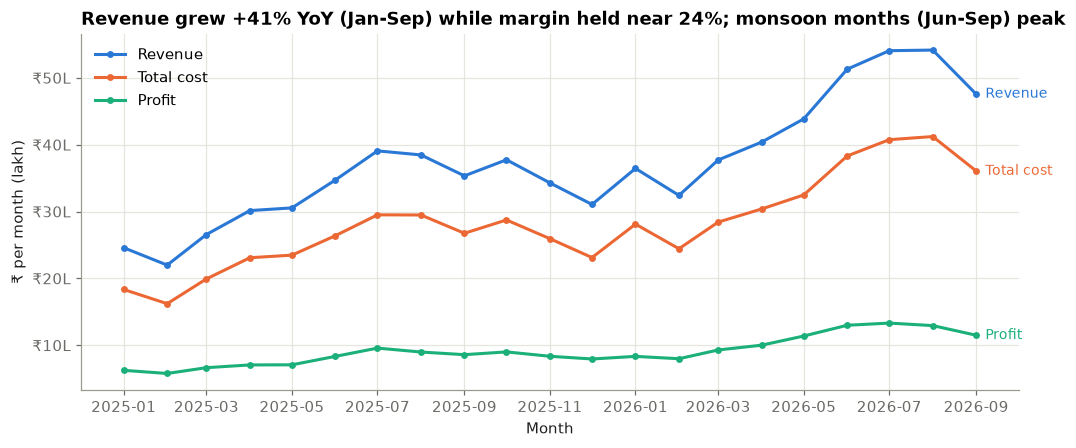

In [6]:
mt = pd.DataFrame(M["monthly_trend"]).set_index("month")
mt.index = pd.PeriodIndex(mt.index, freq="M").to_timestamp()
fig, ax = plt.subplots(figsize=(11, 4.2))
for col, c, lab in [("revenue", BLUE, "Revenue"), ("total_cost", ORANGE, "Total cost"), ("profit", AQUA, "Profit")]:
    ax.plot(mt.index, mt[col], color=c, lw=2, marker="o", ms=3.5, label=lab)
    ax.annotate(lab, (mt.index[-1], mt[col].iloc[-1]), xytext=(6, 0), textcoords="offset points", color=c, va="center", fontsize=9)
ax.yaxis.set_major_formatter(lakh)
ax.set_ylabel("₹ per month (lakh)")
ax.set_xlabel("Month")
y = M["yoy_jan_sep"]
ax.set_title(f"Revenue grew {y['revenue']['pct_change']:+.0%} YoY (Jan-Sep) while margin held near {H['margin']:.0%}; "
             "monsoon months (Jun-Sep) peak")
ax.legend(loc="upper left")
save(fig, "fig01_monthly_revenue_cost_profit")
plt.show()

### 3.2 Volume vs service level (small multiples - one scale per panel)

saved reports/figures/fig02_volume_vs_service_level.png


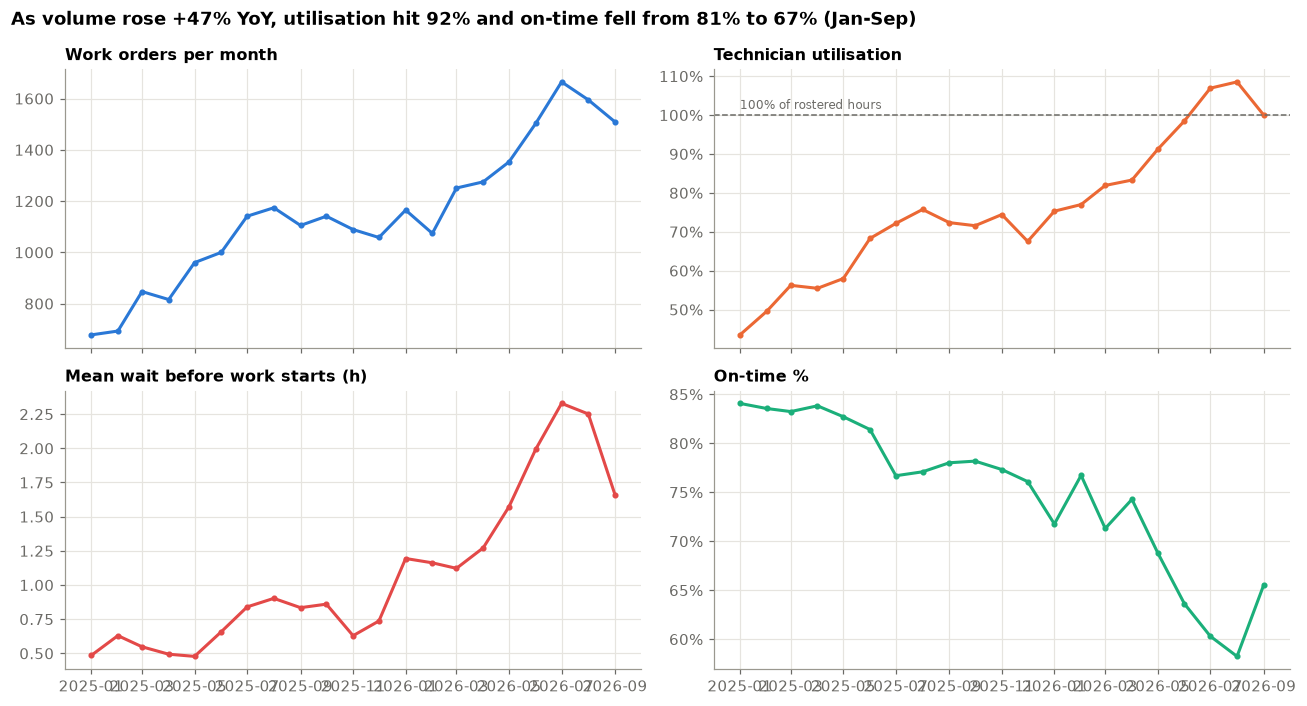

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True)
panels = [("jobs", "Work orders per month", None, BLUE), ("utilisation", "Technician utilisation", pctfmt, ORANGE),
          ("wait_h", "Mean wait before work starts (h)", None, RED), ("on_time", "On-time %", pctfmt, AQUA)]
for ax, (col, title, fmt, c) in zip(axes.flat, panels):
    ax.plot(mt.index, mt[col], color=c, lw=2, marker="o", ms=3)
    ax.set_title(title, fontsize=10.5)
    if fmt is not None:
        ax.yaxis.set_major_formatter(fmt)
axes[0, 1].axhline(1.0, color=MUTED, ls="--", lw=1)
axes[0, 1].annotate("100% of rostered hours", (mt.index[0], 1.0), xytext=(0, 4), textcoords="offset points", fontsize=8, color=MUTED)
fig.suptitle(f"As volume rose {y['jobs']['pct_change']:+.0%} YoY, utilisation hit {y['utilisation']['2026']:.0%} and on-time fell "
             f"from {y['on_time']['2025']:.0%} to {y['on_time']['2026']:.0%} (Jan-Sep)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig02_volume_vs_service_level")
plt.show()

In [8]:
yoy = pd.DataFrame(M["yoy_jan_sep"]).T[["2025", "2026", "change", "pct_change"]]
yoy.loc[["jobs", "revenue", "profit", "margin", "on_time", "tat_median_h", "wait_h", "parts_delay", "utilisation",
         "cancellation_rate", "csat", "csat_pct", "overrun", "comeback"]]

,2025,2026,change,pct_change
jobs,"8,414.000","12,390.000","3,976.000",0.473
revenue,"28,142,374.760","39,788,290.430","11,645,915.670",0.414
profit,"6,825,893.760","9,771,217.630","2,945,323.870",0.431
margin,0.243,0.246,0.003,0.012
on_time,0.807,0.671,-0.136,-0.169
tat_median_h,2.420,2.730,0.310,0.128
wait_h,0.676,1.676,0.999,1.478
parts_delay,0.049,0.046,-0.002,-0.049
utilisation,0.613,0.915,0.303,0.494
cancellation_rate,0.065,0.069,0.004,0.062


**Interpretation.** Jan-Sep 2026 delivered **+47% more jobs and +41% more revenue** than the same months of 2025,
with no change in the 18-technician roster. Over the same window utilisation rose from ~61% to ~92%, mean wait
more than doubled, on-time fell ~14 points and CSAT slipped. Parts-delay rate is flat, so the deterioration
coincides with *capacity* rather than *parts*. That is a time-series association - demand growth, seasonality and
fleet ageing move together - so it motivates the centre-level and day-level analysis below rather than proving
anything on its own.

## 4. Service-centre comparison

In [9]:
cs = pd.DataFrame(M["centre_scorecard"]).set_index("center_id")
view = cs[["center_name", "technicians", "senior_or_master_techs", "jobs", "revenue", "margin", "on_time", "tat_median_h",
           "tat_mean_h", "wait_h", "parts_delay", "utilisation", "utilisation_2026", "overloaded_day_share_2026",
           "cancellation_rate", "mean_lead_days", "qc_first_pass", "comeback", "overrun", "csat"]]
view.sort_values("on_time")

,center_name,technicians,senior_or_master_techs,jobs,revenue,margin,on_time,tat_median_h,tat_mean_h,wait_h,parts_delay,utilisation,utilisation_2026,overloaded_day_share_2026,cancellation_rate,mean_lead_days,qc_first_pass,comeback,overrun,csat
center_id,,,,,,,,,,,,,,,,,,,,
C006,Mumbai - Andheri,2,0,3334,"10,187,470.030",0.271,0.622,2.940,11.207,1.843,0.041,1.021,1.246,0.380,0.086,5.974,0.913,0.055,0.476,3.863
C003,Chennai - Anna Nagar,2,1,3409,"11,323,234.300",0.229,0.654,2.780,12.019,1.980,0.043,0.948,1.185,0.487,0.064,3.087,0.934,0.049,0.336,3.891
C007,Delhi - Saket,2,1,2843,"9,166,823.310",0.237,0.675,2.750,13.512,1.481,0.060,0.828,1.015,0.292,0.062,3.304,0.929,0.053,0.420,3.942
C001,Bengaluru - Indiranagar,3,1,4117,"13,643,835.490",0.252,0.753,2.600,9.321,0.857,0.036,0.804,0.949,0.231,0.071,3.865,0.929,0.047,0.401,4.062
C008,Kolkata - Salt Lake,2,2,2139,"7,158,503.800",0.238,0.778,2.340,18.685,0.928,0.112,0.555,0.672,0.142,0.064,3.028,0.950,0.037,0.268,4.052
C002,Bengaluru - Whitefield,3,2,3894,"12,437,229.180",0.248,0.787,2.460,8.196,0.673,0.031,0.735,0.858,0.171,0.063,3.071,0.934,0.042,0.375,4.125
C004,Hyderabad - Gachibowli,2,1,2239,"7,613,333.430",0.252,0.815,2.400,9.603,0.730,0.036,0.621,0.756,0.155,0.065,3.093,0.929,0.033,0.334,4.138
C005,Pune - Baner,2,2,2117,"6,708,233.840",0.219,0.831,2.250,9.679,0.959,0.043,0.526,0.653,0.165,0.062,3.150,0.956,0.034,0.231,4.137


saved reports/figures/fig03_centre_on_time_utilisation_wait.png


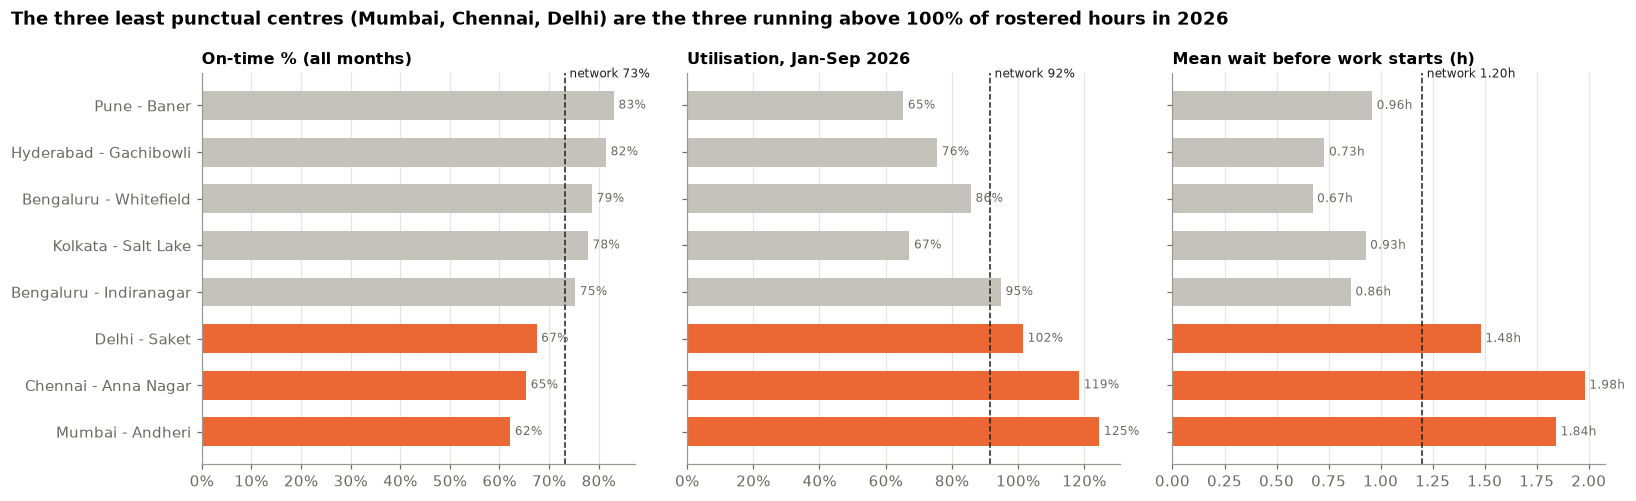

In [10]:
order = cs.sort_values("on_time").index
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
def hbar(ax, col, title, bench, fmt=pctfmt, hl=("C006", "C003", "C007"), hl_color=ORANGE):
    vals = cs.loc[order, col]
    colors = [hl_color if c in hl else GREY for c in order]
    ax.barh([NAMES[c] for c in order], vals, color=colors, height=0.62)
    ax.axvline(bench, color=INK, ls="--", lw=1)
    ax.annotate(f"network {fmt(bench) if callable(fmt) else bench}", (bench, len(order) - 0.4), xytext=(3, 0),
                textcoords="offset points", fontsize=8, color=INK)
    for i, v in enumerate(vals):
        ax.annotate(fmt(v) if callable(fmt) else f"{v:.2f}", (v, i), xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=MUTED)
    ax.set_title(title, fontsize=10.5)
    ax.grid(axis="y", visible=False)
f_pct = lambda v: f"{v:.0%}"
hbar(axes[0], "on_time", "On-time % (all months)", H["on_time_rate"], f_pct)
t26 = ftm[ftm["month"].str.startswith("2026")]
hbar(axes[1], "utilisation_2026", "Utilisation, Jan-Sep 2026", t26["service_hours"].sum() / t26["available_hours"].sum(), f_pct)
hbar(axes[2], "wait_h", "Mean wait before work starts (h)", H["avg_wait_h"], lambda v: f"{v:.2f}h")
for ax in axes[:2]:
    ax.xaxis.set_major_formatter(pctfmt)
fig.suptitle("The three least punctual centres (Mumbai, Chennai, Delhi) are the three running above 100% of rostered hours in 2026",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig03_centre_on_time_utilisation_wait")
plt.show()

In [11]:
T = M["statistical_tests"]
tests = pd.DataFrame([
    ("Turnaround differs across centres", "Kruskal-Wallis", f"H={T['kruskal_turnaround_by_centre']['H']:.0f}", T["kruskal_turnaround_by_centre"]["p"],
     f"ε²={T['kruskal_turnaround_by_centre']['epsilon_sq']:.3f}", "small"),
    ("Wait differs across centres", "Kruskal-Wallis", f"H={T['kruskal_wait_by_centre']['H']:.0f}", T["kruskal_wait_by_centre"]["p"],
     f"ε²={T['kruskal_wait_by_centre']['epsilon_sq']:.3f}", "small"),
    ("Wait: Mumbai vs rest of network", "Mann-Whitney U", f"median {T['mannwhitney_wait_focus_vs_rest']['median_focus_h']:.2f}h vs {T['mannwhitney_wait_focus_vs_rest']['median_rest_h']:.2f}h",
     T["mannwhitney_wait_focus_vs_rest"]["p"], f"rank-biserial r={T['mannwhitney_wait_focus_vs_rest']['rank_biserial']:.2f}", "small"),
    ("On-time differs across centres", "Chi-square", f"χ²={T['chi2_on_time_by_centre']['chi2']:.0f}", T["chi2_on_time_by_centre"]["p"],
     f"Cramér's V={T['chi2_on_time_by_centre']['cramers_v']:.2f}", "small-moderate"),
    ("On-time: Mumbai vs Pune (best)", "Two-proportion",
     f"gap {T['on_time_gap_focus_vs_benchmark']['gap']:+.1%} (95% CI {T['on_time_gap_focus_vs_benchmark']['ci95_low']:+.1%} to {T['on_time_gap_focus_vs_benchmark']['ci95_high']:+.1%})",
     np.nan, f"Cohen's h={T['on_time_gap_focus_vs_benchmark']['cohens_h']:.2f}", "small-medium"),
], columns=["question", "test", "statistic", "p_value", "effect size", "magnitude"])
tests

,question,test,statistic,p_value,effect size,magnitude
0,Turnaround differs across centres,Kruskal-Wallis,H=578,0.000,ε²=0.024,small
1,Wait differs across centres,Kruskal-Wallis,H=742,0.000,ε²=0.031,small
2,Wait: Mumbai vs rest of network,Mann-Whitney U,median 0.43h vs 0.31h,0.000,rank-biserial r=0.13,small
3,On-time differs across centres,Chi-square,χ²=635,0.000,Cramér's V=0.16,small-moderate
4,On-time: Mumbai vs Pune (best),Two-proportion,gap -20.9% (95% CI -23.2% to -18.6%),NaN,Cohen's h=-0.48,small-medium


**Interpretation.**
* Centre differences are real (p ≪ 0.001) but individually **small-to-moderate** in effect size: most jobs at every
  centre are quick. The gap is concentrated in the *tail* - overloaded days and parts-delayed jobs - which is
  why means diverge far more than medians.
* **Mumbai - Andheri** is the weakest operationally: lowest on-time (62%), 125% utilisation in 2026, the longest
  booking lead time (≈6 days vs ≈3 elsewhere), the highest cancellation rate and the highest cost-overrun rate.
  It also has **no Senior or Master technician**.
* **Chennai - Anna Nagar** and **Delhi - Saket** show the same capacity signature (118% and 102% utilisation in 2026).
* **Kolkata - Salt Lake** has a *different* problem: average utilisation (67% in 2026) and decent on-time, but
  the **highest mean turnaround (18.7 h)** because 11% of its jobs wait for parts - 2-3× any other centre.
* Pune and Hyderabad are the benchmarks: lowest utilisation, highest on-time and CSAT.

## 5. Technician comparison

In [12]:
ts = pd.DataFrame(M["technician_scorecard"]).set_index("technician_id")
ts[["center_name", "skill_level", "jobs", "utilisation", "utilisation_2026", "on_time", "qc_first_pass", "comeback",
    "duration_var_h", "overrun", "csat", "margin"]].sort_values("utilisation_2026", ascending=False)

,center_name,skill_level,jobs,utilisation,utilisation_2026,on_time,qc_first_pass,comeback,duration_var_h,overrun,csat,margin
technician_id,,,,,,,,,,,,
T013,Mumbai - Andheri,Junior,1683,1.074,1.323,0.578,0.902,0.053,0.666,0.573,3.855,0.286
T016,Delhi - Saket,Junior,1679,1.043,1.289,0.628,0.906,0.059,0.649,0.562,3.884,0.296
T007,Chennai - Anna Nagar,Mid,1809,1.026,1.267,0.641,0.928,0.050,0.347,0.362,3.864,0.252
T014,Mumbai - Andheri,Mid,1640,0.967,1.168,0.668,0.924,0.056,0.358,0.376,3.869,0.257
T008,Chennai - Anna Nagar,Senior,1592,0.871,1.103,0.668,0.941,0.048,0.177,0.306,3.921,0.207
T002,Bengaluru - Indiranagar,Junior,1492,0.926,1.090,0.709,0.907,0.056,0.641,0.548,4.029,0.295
T005,Bengaluru - Whitefield,Junior,1469,0.917,1.048,0.723,0.911,0.053,0.634,0.543,4.071,0.294
T003,Bengaluru - Indiranagar,Mid,1411,0.806,0.946,0.766,0.934,0.041,0.323,0.359,4.039,0.259
T009,Hyderabad - Gachibowli,Mid,1192,0.678,0.814,0.792,0.914,0.043,0.347,0.382,4.109,0.277


saved reports/figures/fig04_technician_utilisation_heatmap.png


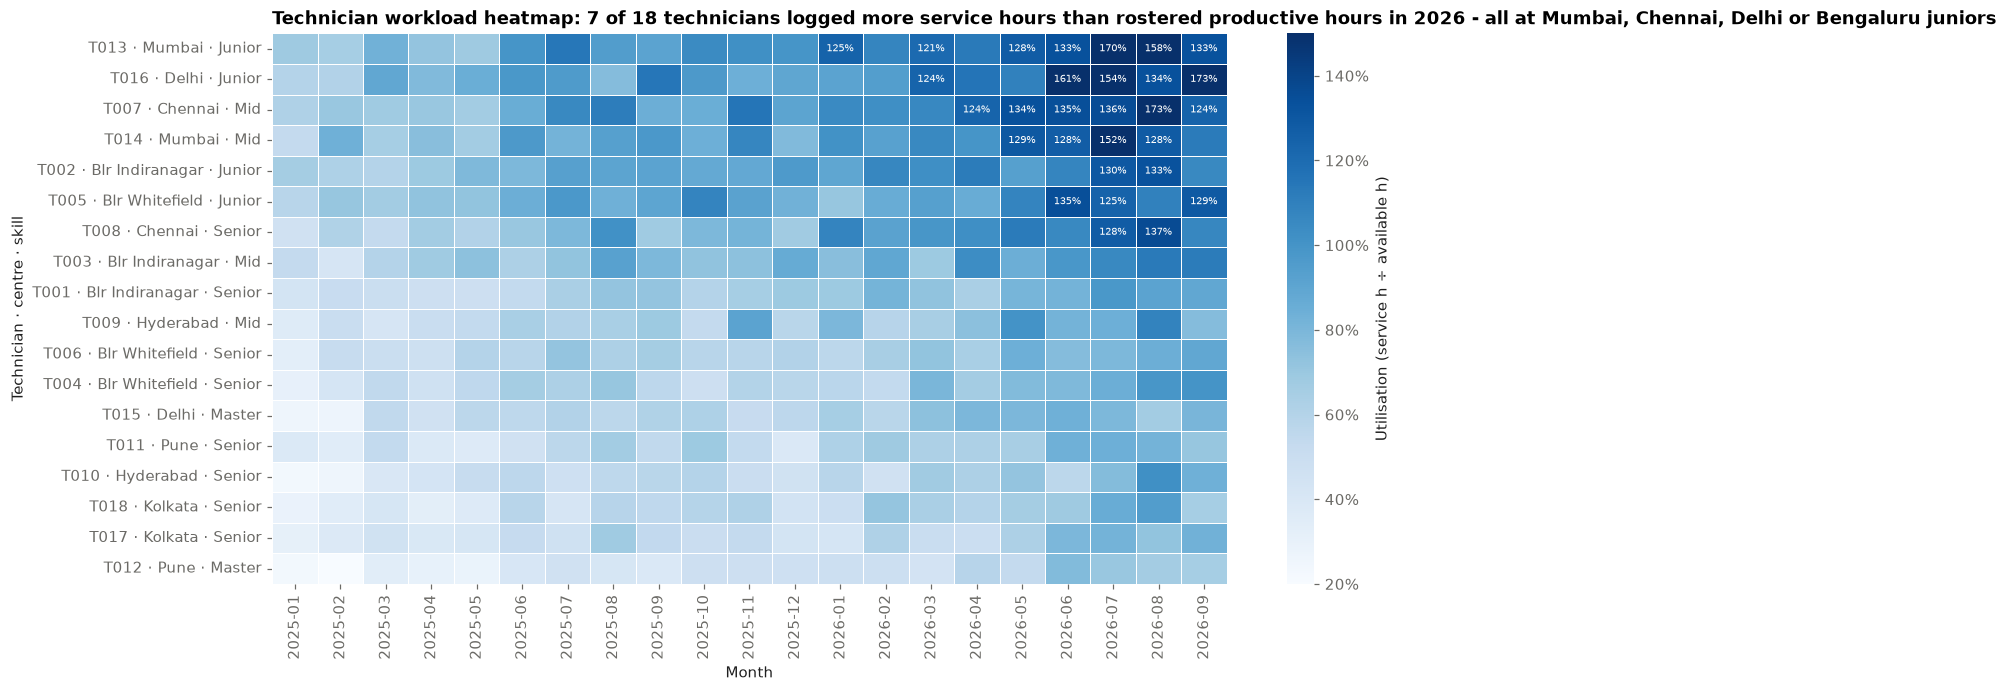

In [13]:
hm = ftm.assign(label=lambda x: x["technician_id"] + " · " + x["center_id"].map(SHORT) + " · " + x["skill_level"]) \
        .pivot_table(index="label", columns="month", values="utilisation")
hm = hm.loc[hm.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(14, 6.5))
sns.heatmap(hm, cmap="Blues", vmin=0.2, vmax=1.5, cbar_kws={"label": "Utilisation (service h ÷ available h)", "format": pctfmt},
            linewidths=0.4, linecolor="white", ax=ax)
for (i, j), v in np.ndenumerate(hm.to_numpy()):
    if v > 1.2:
        ax.text(j + 0.5, i + 0.5, f"{v:.0%}", ha="center", va="center", fontsize=6.5, color="white")
ax.set_xlabel("Month")
ax.set_ylabel("Technician · centre · skill")
n_over = int((ftm[ftm["month"].str.startswith("2026")].groupby("technician_id")["service_hours"].sum()
              / ftm[ftm["month"].str.startswith("2026")].groupby("technician_id")["available_hours"].sum() > 1).sum())
ax.set_title(f"Technician workload heatmap: {n_over} of 18 technicians logged more service hours than rostered productive hours in 2026 - "
             "all at Mumbai, Chennai, Delhi or Bengaluru juniors")
save(fig, "fig04_technician_utilisation_heatmap")
plt.show()

**Interpretation.** Overload is concentrated, not network-wide. The most loaded technicians are the Mumbai pair
(T013 Junior, T014 Mid), Chennai (T007, T008), Delhi's junior (T016) and the Bengaluru juniors - who also absorb a
disproportionate share of simple jobs. Meanwhile Pune, Hyderabad and Kolkata technicians sit at 59-81% in 2026.
Utilisation above 100% means booked labour exceeded the 7 productive hours per day the roster provides; the data
holds no overtime or attendance records, so we cannot tell whether that was absorbed by overtime or by jobs
spilling into the next day (the latter is consistent with the longer waits).

## 6. Service-type comparison

In [14]:
st = pd.DataFrame(M["service_type_scorecard"]).set_index("service_type")
st[["jobs", "revenue", "margin", "avg_service_cost", "on_time", "tat_median_h", "tat_mean_h", "parts_delay", "overrun",
    "comeback", "csat"]].sort_values("on_time")

,jobs,revenue,margin,avg_service_cost,on_time,tat_median_h,tat_mean_h,parts_delay,overrun,comeback,csat
service_type,,,,,,,,,,,
Accident & Body Repair,585,"7,115,324.230",0.291,"8,620.192",0.438,20.120,42.454,0.168,0.289,0.062,3.612
Motor & Controller Repair,401,"6,077,717.140",0.130,"13,190.830",0.489,8.140,63.318,0.214,0.282,0.077,3.657
Charging System Repair,668,"4,621,695.070",0.167,"5,764.691",0.618,3.730,29.690,0.138,0.316,0.070,3.785
Suspension Service,562,"3,317,258.600",0.298,"4,145.802",0.635,3.790,16.185,0.060,0.365,0.039,3.882
Electrical Diagnostics,1118,"7,961,404.910",0.147,"6,076.679",0.637,3.060,36.686,0.142,0.340,0.071,3.834
Belt Drive Service,933,"5,219,389.680",0.271,"4,080.056",0.682,2.970,16.825,0.071,0.236,0.048,3.930
Brake Service,1638,"4,848,337.330",0.339,"1,956.993",0.716,2.650,8.897,0.052,0.316,0.063,3.982
Tyre Replacement,1395,"6,148,902.750",0.250,"3,305.860",0.741,1.940,9.693,0.076,0.151,0.062,4.015
Periodic Service,14205,"25,437,124.990",0.283,"1,283.711",0.756,2.540,6.014,0.023,0.393,0.034,4.073


saved reports/figures/fig05_service_type_parts_vs_on_time.png


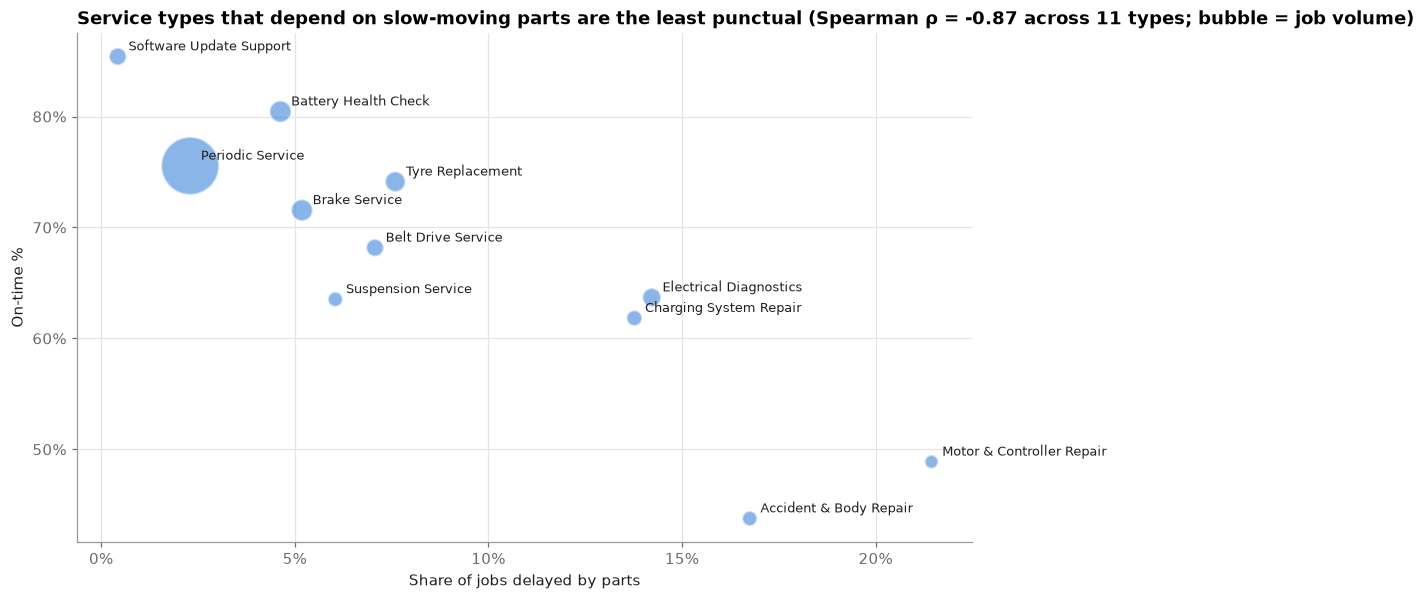

In [15]:
fig, ax = plt.subplots(figsize=(10.5, 6))
sizes = st["jobs"] / st["jobs"].max() * 1400 + 40
ax.scatter(st["parts_delay"], st["on_time"], s=sizes, color=BLUE, alpha=0.55, edgecolor="white", linewidth=1.5)
for name, r in st.iterrows():
    ax.annotate(name, (r["parts_delay"], r["on_time"]), xytext=(7, 4), textcoords="offset points", fontsize=8.5, color=INK)
rho, p = stats.spearmanr(st["parts_delay"], st["on_time"])
ax.xaxis.set_major_formatter(pctfmt)
ax.yaxis.set_major_formatter(pctfmt)
ax.set_xlabel("Share of jobs delayed by parts")
ax.set_ylabel("On-time %")
ax.set_title(f"Service types that depend on slow-moving parts are the least punctual (Spearman ρ = {rho:.2f} across 11 types; bubble = job volume)")
save(fig, "fig05_service_type_parts_vs_on_time")
plt.show()

**Interpretation.** Motor & controller repair (49% on-time, 21% parts-delayed) and accident & body repair (44%,
17%) are the least reliable services, followed by charging and electrical work. These are also the lowest-margin
repairs (13-17% for motor and electrical work) because expensive parts and long labour are partly covered by
warranty rates. Software-update support is the most punctual - but has the highest cancellation rate (10.7%)
because many issues are resolved over the air before the visit.

## 7. Vehicle-model comparison

In [16]:
mo = pd.DataFrame(M["model_scorecard"]).set_index("model")
display(mo[["jobs", "revenue", "margin", "avg_service_cost", "on_time", "tat_mean_h", "parts_delay", "qc_first_pass", "comeback", "csat"]])
display(fs.groupby(["model", "year"])["parts_delay_flag"].mean().unstack().style.format("{:.1%}"))

,jobs,revenue,margin,avg_service_cost,on_time,tat_mean_h,parts_delay,qc_first_pass,comeback,csat
model,,,,,,,,,,
Ather 450 Apex,1289,"4,697,283.730",0.258,"2,703.201",0.716,13.132,0.052,0.938,0.042,4.012
Ather 450X,13906,"48,956,476.220",0.243,"2,664.130",0.734,11.827,0.051,0.932,0.048,4.016
Ather Rizta,8897,"24,584,903.430",0.244,"2,088.427",0.732,9.848,0.041,0.932,0.041,4.029


year,2025,2026
model,,
Ather 450 Apex,6.1%,4.4%
Ather 450X,5.1%,5.1%
Ather Rizta,4.0%,4.1%


**Interpretation.** Model differences are small. The Ather 450 Apex has slightly lower on-time and the highest
parts-delay rate (5.2%, consistent with Apex-specific parts having thinner stock), but it is only 5% of volume.
Rizta jobs are cheapest to serve (younger fleet, lower average cost). **Model is not a primary driver** of the
service-level problems - centre, day and parts effects are much larger.

## 8. Distributions and outliers

In [17]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int((s > q3 + 1.5 * (q3 - q1)).sum())
out = pd.DataFrame({c: {"IQR-outliers (high)": iqr_outliers(fs[c].dropna()), "p95": fs[c].quantile(0.95), "max": fs[c].max()}
                    for c in ["turnaround_hours", "wait_hours", "late_hours", "cost_variance_pct", "revenue", "duration_variance_hours"]}).T
out["share_of_jobs"] = out["IQR-outliers (high)"] / len(fs)
out

,IQR-outliers (high),p95,max,share_of_jobs
turnaround_hours,"3,449.000",46.500,577.370,0.143
wait_hours,"2,579.000",2.996,71.990,0.107
late_hours,"5,457.000",42.120,572.120,0.227
cost_variance_pct,"3,065.000",1.247,103.118,0.127
revenue,"2,273.000","11,074.913","69,159.380",0.094
duration_variance_hours,"1,116.000",1.420,4.990,0.046


saved reports/figures/fig06_turnaround_and_wait_distributions.png


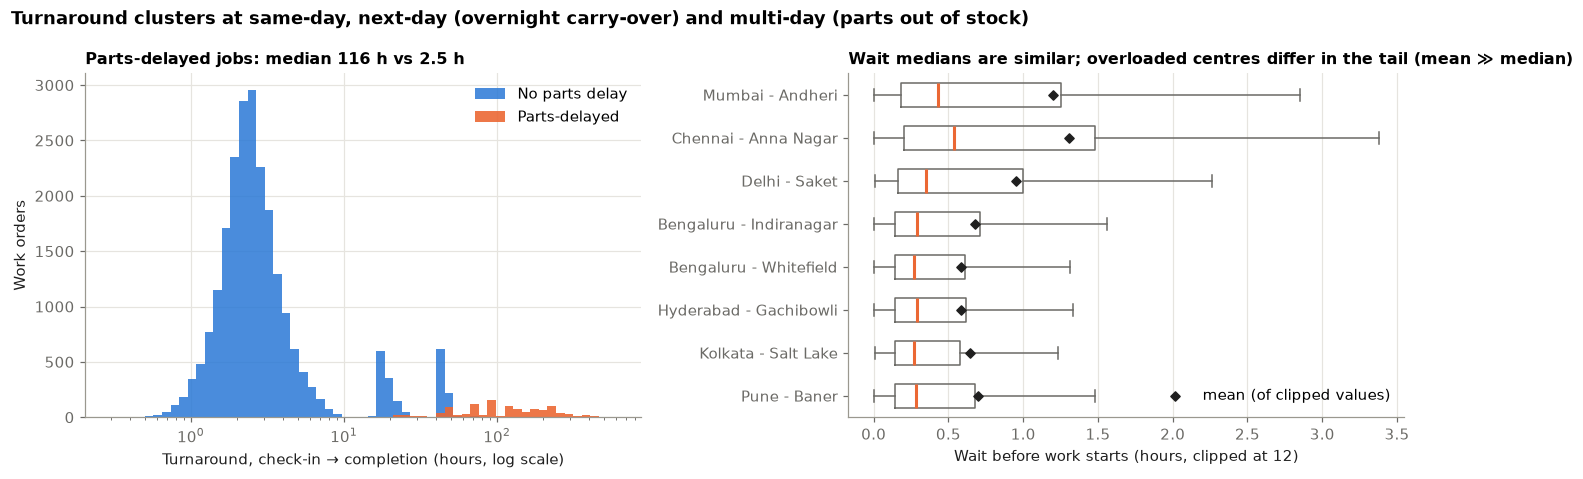

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bins = np.logspace(np.log10(0.3), np.log10(600), 60)
axes[0].hist(fs.loc[~fs["parts_delay_flag"], "turnaround_hours"], bins=bins, color=BLUE, alpha=0.85, label="No parts delay")
axes[0].hist(fs.loc[fs["parts_delay_flag"], "turnaround_hours"], bins=bins, color=ORANGE, alpha=0.9, label="Parts-delayed")
axes[0].set_xscale("log")
axes[0].set_xlabel("Turnaround, check-in → completion (hours, log scale)")
axes[0].set_ylabel("Work orders")
axes[0].legend()
pdi = pd.DataFrame(M["parts_delay_impact"]).set_index("parts_delay_flag")
axes[0].set_title(f"Parts-delayed jobs: median {pdi.loc[True, 'tat_median_h']:.0f} h vs {pdi.loc[False, 'tat_median_h']:.1f} h", fontsize=10.5)
order_c = cs.sort_values("tat_median_h").index
data = [fs.loc[fs["center_id"] == c, "wait_hours"].dropna().clip(upper=12) for c in order_c]
axes[1].boxplot(data, orientation="horizontal", tick_labels=[NAMES[c] for c in order_c], showfliers=False, widths=0.55,
                medianprops={"color": ORANGE, "lw": 2}, boxprops={"color": MUTED}, whiskerprops={"color": MUTED}, capprops={"color": MUTED})
axes[1].scatter([x.mean() for x in data], range(1, len(data) + 1), color=INK, marker="D", s=18, zorder=3, label="mean (of clipped values)")
axes[1].set_xlabel("Wait before work starts (hours, clipped at 12)")
axes[1].legend(loc="lower right")
axes[1].set_title("Wait medians are similar; overloaded centres differ in the tail (mean ≫ median)", fontsize=10.5)
axes[1].grid(axis="y", visible=False)
fig.suptitle("Turnaround clusters at same-day, next-day (overnight carry-over) and multi-day (parts out of stock)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig06_turnaround_and_wait_distributions")
plt.show()

In [19]:
co = M["overnight_carry_over"]
print(f"Jobs with NO parts delay that still finish on a later day than check-in: {co['network_share']:.1%} "
      f"(on-time {co['on_time_if_carried_over']:.0%} vs {co['on_time_if_same_day']:.0%} for same-day completions)")
display(pd.DataFrame({"carry_over_share": co["by_centre"]}).rename(index=NAMES).sort_values("carry_over_share", ascending=False).T)
display(pd.DataFrame({"carry_over_share": co["by_weekday"]}).reindex(am.WEEKDAY_ORDER).T)

Jobs with NO parts delay that still finish on a later day than check-in: 8.8% (on-time 29% vs 81% for same-day completions)


,Mumbai - Andheri,Chennai - Anna Nagar,Delhi - Saket,Bengaluru - Indiranagar,Bengaluru - Whitefield,Hyderabad - Gachibowli,Pune - Baner,Kolkata - Salt Lake
carry_over_share,0.128,0.119,0.097,0.087,0.070,0.064,0.062,0.052


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday
carry_over_share,0.064,0.071,0.067,0.063,0.069,0.158


**Interpretation.** Turnaround has three clusters: same-day jobs (a few hours), jobs that carry over to the next
working day (the ~18 h and ~42 h peaks - overnight and over-Sunday), and parts-delayed jobs (median ≈116 h, ~5 days).
Only 4.7% of jobs are parts-delayed but they account for most of the mean turnaround. Carry-over without any
parts delay is a capacity signal: it happens to ~9% of non-parts jobs network-wide, 12-13% at Mumbai and Chennai and
16% of Saturday jobs (which carry over to Monday), and those jobs are on time only ~29% of the time.
The `cost_variance_pct` maximum (>100×) comes from jobs with a tiny estimate that turned into a major parts
replacement - a reminder that percentage overruns need an absolute floor in reporting. These outliers are real
operational events, not data errors, so they are **kept**; robust statistics are used instead.

## 9. Relationships: workload → delays → cost → satisfaction
### 9.1 Correlation overview (Spearman, job level)

saved reports/figures/fig07_spearman_correlation_matrix.png


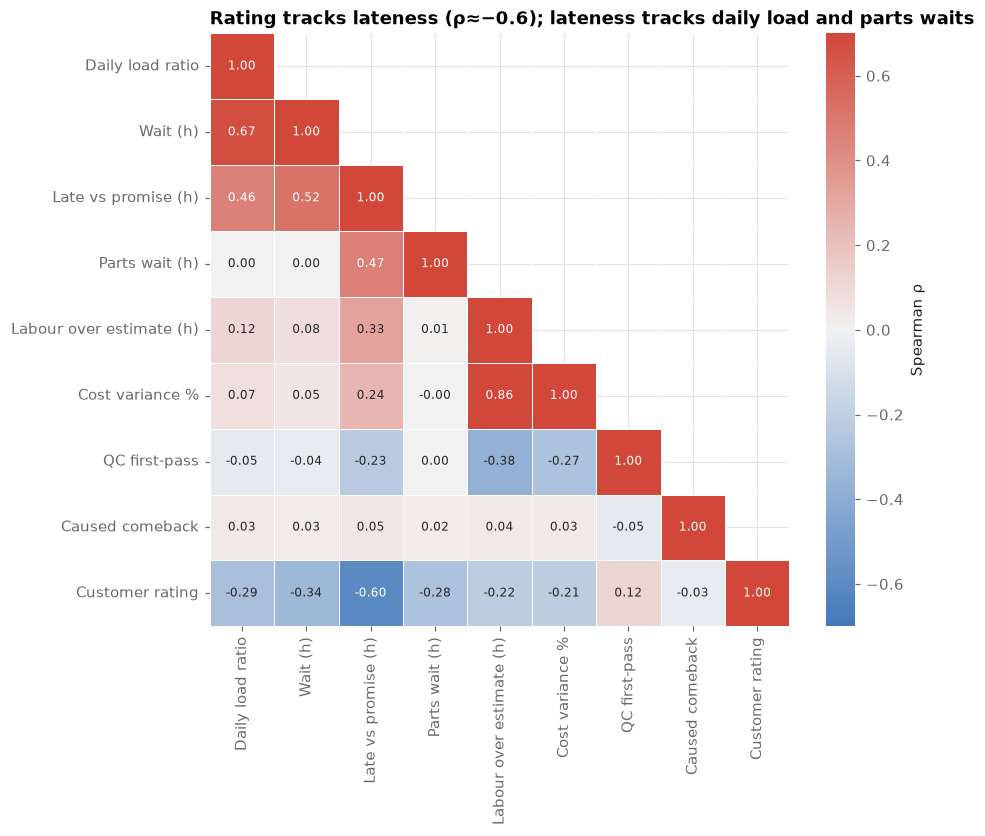

In [20]:
corr_cols = {"load_ratio": "Daily load ratio", "wait_hours": "Wait (h)", "late_hours": "Late vs promise (h)",
             "parts_wait_hours": "Parts wait (h)", "duration_variance_hours": "Labour over estimate (h)",
             "cost_variance_pct": "Cost variance %", "qc_passed_first_time": "QC first-pass", "caused_repeat_visit": "Caused comeback",
             "rating": "Customer rating"}
cm = fsl[list(corr_cols)].astype(float).rename(columns=corr_cols).corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, mask=mask, cmap=sns.diverging_palette(250, 15, s=75, l=50, as_cmap=True), vmin=-0.7, vmax=0.7, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5, cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("Rating tracks lateness (ρ≈−0.6); lateness tracks daily load and parts waits")
save(fig, "fig07_spearman_correlation_matrix")
plt.show()

### 9.2 Daily workload and service level

For every centre-day we compute **load ratio = booked estimated hours ÷ (rostered technicians × 7 productive h)**.
This is the clearest operational lever in the data.

,jobs,on_time,wait_h,qc_first_pass,comeback,csat
load_band,,,,,,
"(0.0, 0.6]",7270,0.901,0.231,0.943,0.037,4.226
"(0.6, 0.7]",2693,0.894,0.253,0.934,0.046,4.230
"(0.7, 0.8]",2620,0.889,0.255,0.940,0.047,4.229
"(0.8, 0.9]",2180,0.856,0.402,0.939,0.035,4.216
"(0.9, 1.0]",2342,0.772,0.672,0.937,0.038,4.121
"(1.0, 1.1]",1383,0.610,1.031,0.921,0.056,3.861
"(1.1, 1.2]",1215,0.506,1.563,0.933,0.054,3.768
"(1.2, 1.4]",1834,0.375,2.180,0.911,0.053,3.640
"(1.4, 1.6]",1239,0.253,3.866,0.901,0.069,3.429


saved reports/figures/fig08_daily_load_vs_service_level.png


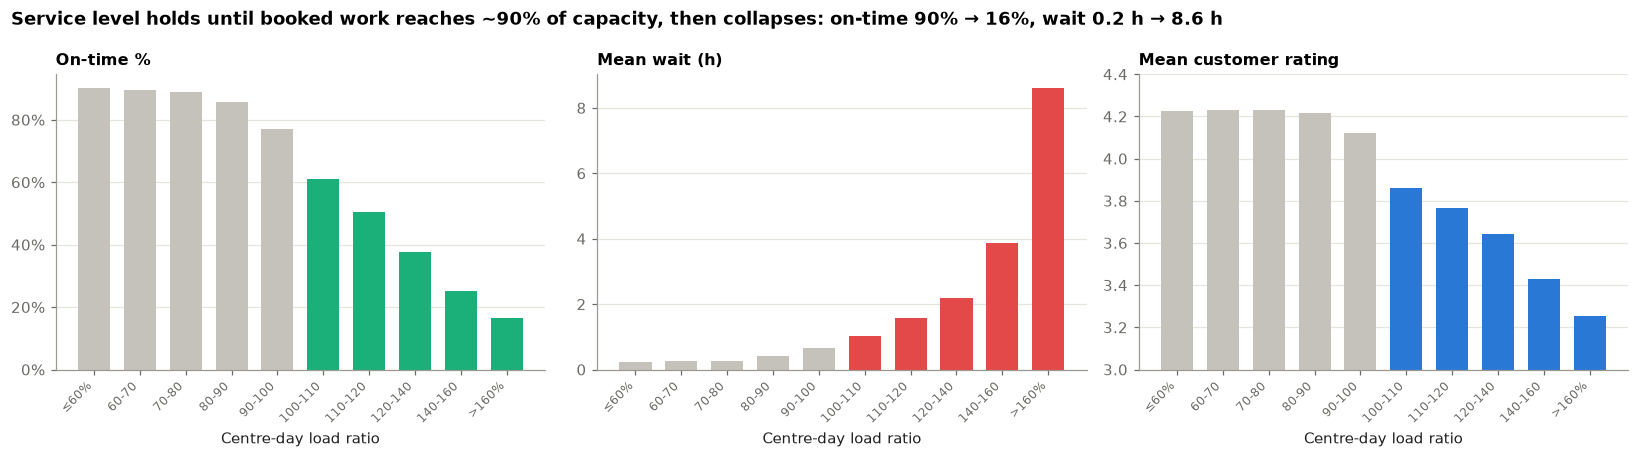

Centre-day level (n=4,305): Spearman load vs mean wait ρ=0.63; load vs on-time ρ=-0.56 (both p<0.001)


,center_name,overloaded_day_share,overloaded_day_share_2026
center_id,,,
C003,Chennai - Anna Nagar,0.315,0.487
C006,Mumbai - Andheri,0.260,0.380
C007,Delhi - Saket,0.170,0.292
C001,Bengaluru - Indiranagar,0.133,0.231
C002,Bengaluru - Whitefield,0.106,0.171
C005,Pune - Baner,0.096,0.165
C004,Hyderabad - Gachibowli,0.090,0.155
C008,Kolkata - Salt Lake,0.085,0.142


In [21]:
lb = pd.DataFrame(M["load_band_profile"]).set_index("load_band")
display(lb)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
labels = ["≤60%", "60-70", "70-80", "80-90", "90-100", "100-110", "110-120", "120-140", "140-160", ">160%"]
x = np.arange(len(lb))
for ax, col, title, fmt, c in [(axes[0], "on_time", "On-time %", pctfmt, AQUA), (axes[1], "wait_h", "Mean wait (h)", None, RED),
                               (axes[2], "csat", "Mean customer rating", None, BLUE)]:
    ax.bar(x, lb[col], color=[c if i >= 5 else GREY for i in range(len(lb))], width=0.7)
    ax.set_xticks(x, labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel("Centre-day load ratio")
    ax.grid(axis="x", visible=False)
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
axes[2].set_ylim(3, 4.4)
fig.suptitle(f"Service level holds until booked work reaches ~90% of capacity, then collapses: on-time {lb['on_time'].iloc[0]:.0%} → {lb['on_time'].iloc[-1]:.0%}, "
             f"wait {lb['wait_h'].iloc[0]:.1f} h → {lb['wait_h'].iloc[-1]:.1f} h", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig08_daily_load_vs_service_level")
plt.show()
r1, r2 = T["spearman_daily_load_vs_wait"], T["spearman_daily_load_vs_on_time"]
print(f"Centre-day level (n={r1['n']:,}): Spearman load vs mean wait ρ={r1['rho']:.2f}; load vs on-time ρ={r2['rho']:.2f} (both p<0.001)")
od = cs[["center_name", "overloaded_day_share", "overloaded_day_share_2026"]].sort_values("overloaded_day_share_2026", ascending=False)
od

**Interpretation.** The relationship is non-linear - a classic queueing knee. Below ~80-90% load, on-time is ~89%
and wait is ~15 minutes; above 100% load on-time falls to 61% and then to 16% on the busiest days, with waits of
several hours. QC first-pass and comebacks also worsen modestly on overloaded days. At centre-day level the
correlations are **large** (|ρ| ≈ 0.56-0.63). In 2026, Chennai was overloaded on **49%** of working days and
Mumbai on **38%**, versus 14-17% at the benchmark centres.

*Caveat:* load is measured from booked estimated hours. A day can look overloaded because a few long repairs
arrived together; equally, a centre with slower (junior) technicians is effectively more loaded than this ratio
shows.

### 9.3 Lateness, parts delays and satisfaction

saved reports/figures/fig09_csat_by_lateness.png


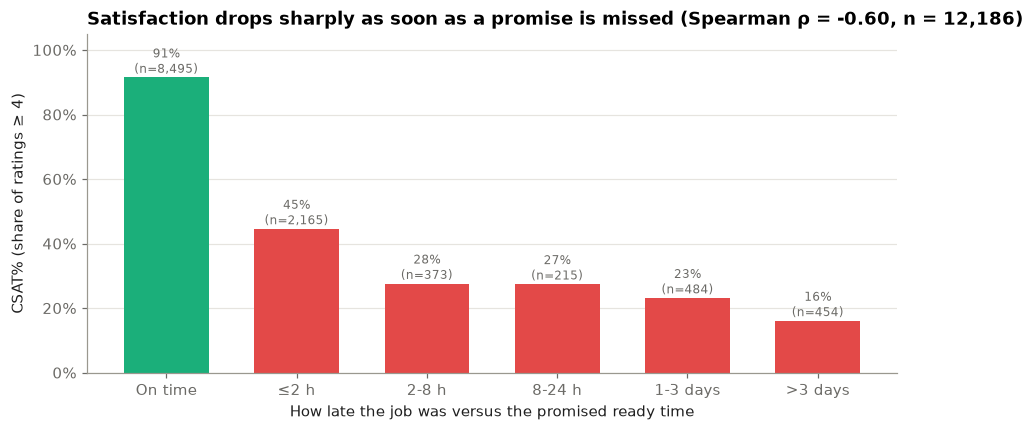

Chi-square on-time × parts delay: χ²=3246, p<0.001, Cramér's V=0.37 (moderate-strong)


,jobs,on_time,tat_mean_h,tat_median_h,parts_wait_mean_h,csat,csat_pct
parts_delay_flag,,,,,,,
False,22958,0.768,5.054,2.510,0.000,4.083,0.777
True,1134,0.000,134.904,116.370,129.131,2.951,0.211


In [22]:
r = fs.dropna(subset=["rating"]).copy()
r["late_band"] = pd.cut(r["late_hours"], [-0.01, 0, 2, 8, 24, 72, np.inf], labels=["On time", "≤2 h", "2-8 h", "8-24 h", "1-3 days", ">3 days"])
rb = r.groupby("late_band", observed=True).agg(responses=("rating", "size"), csat=("rating", "mean"),
                                              csat_pct=("rating", lambda s: (s >= 4).mean()))
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(rb.index.astype(str), rb["csat_pct"], color=[AQUA] + [RED] * (len(rb) - 1), width=0.65)
for i, (v, n) in enumerate(zip(rb["csat_pct"], rb["responses"])):
    ax.annotate(f"{v:.0%}\n(n={n:,})", (i, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=MUTED)
ax.yaxis.set_major_formatter(pctfmt)
ax.set_ylim(0, 1.05)
ax.set_ylabel("CSAT% (share of ratings ≥ 4)")
ax.set_xlabel("How late the job was versus the promised ready time")
s = T["spearman_rating_vs_late_hours"]
ax.set_title(f"Satisfaction drops sharply as soon as a promise is missed (Spearman ρ = {s['rho']:.2f}, n = {s['n']:,})")
ax.grid(axis="x", visible=False)
save(fig, "fig09_csat_by_lateness")
plt.show()
c = T["chi2_on_time_vs_parts_delay"]
print(f"Chi-square on-time × parts delay: χ²={c['chi2']:.0f}, p<0.001, Cramér's V={c['cramers_v']:.2f} (moderate-strong)")
display(pd.DataFrame(M["parts_delay_impact"]).set_index("parts_delay_flag"))

**Interpretation.** Missing the promised time is the single strongest correlate of a poor rating: CSAT% is ~91%
for on-time jobs, 45% when up to 2 h late and below 30% beyond that. **No parts-delayed job met its
promise** (0% on-time), because the promise rule does not allow for a supplier wait; those customers rate 2.95 on
average. Waiting time before work starts has a weaker but clear association with rating (ρ ≈ −0.34).

## 10. Day-of-week pattern (peak-day waiting)

,jobs,on_time,wait_h,csat,appointments,cancellation_rate,job_share
weekday,,,,,,,
Monday,3957,0.785,0.664,4.091,4475,0.089,0.164
Tuesday,3558,0.796,0.578,4.109,3967,0.067,0.148
Wednesday,3474,0.793,0.628,4.131,3850,0.068,0.144
Thursday,3543,0.813,0.487,4.130,3948,0.062,0.147
Friday,3843,0.763,0.736,4.047,4217,0.057,0.160
Saturday,5717,0.548,3.057,3.777,6312,0.063,0.237


saved reports/figures/fig10_weekday_peak.png


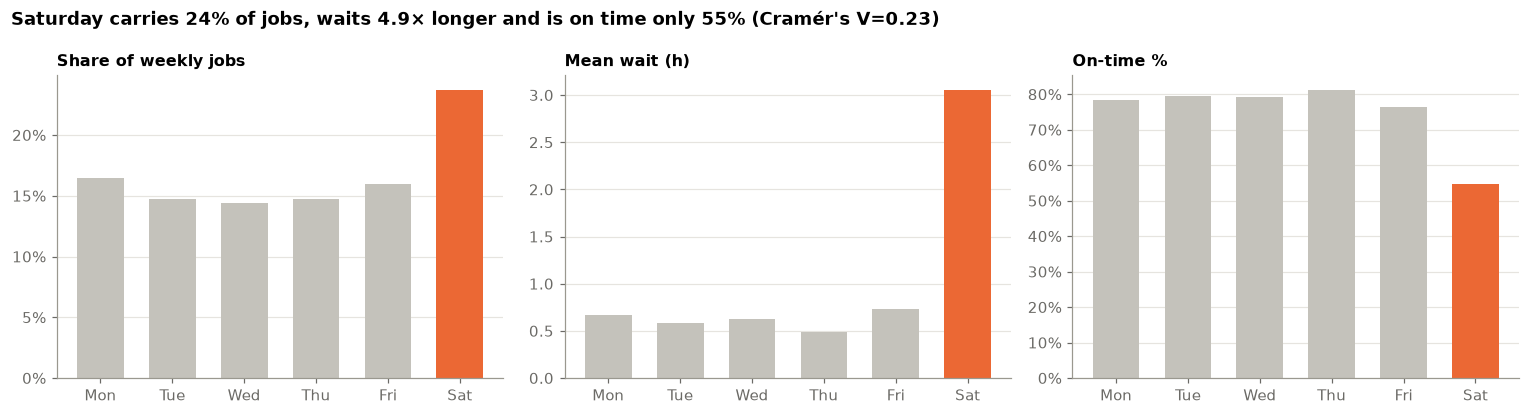

In [23]:
wd = pd.DataFrame(M["weekday_profile"]).set_index("weekday")
display(wd)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, title, fmt in [(axes[0], "job_share", "Share of weekly jobs", pctfmt), (axes[1], "wait_h", "Mean wait (h)", None),
                            (axes[2], "on_time", "On-time %", pctfmt)]:
    ax.bar(wd.index.str[:3], wd[col], color=[ORANGE if d == "Saturday" else GREY for d in wd.index], width=0.65)
    ax.set_title(title, fontsize=10.5)
    ax.grid(axis="x", visible=False)
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
cs2 = T["chi2_on_time_saturday_vs_weekday"]
fig.suptitle(f"Saturday carries {wd.loc['Saturday', 'job_share']:.0%} of jobs, waits {wd.loc['Saturday', 'wait_h'] / wd.drop('Saturday')['wait_h'].mean():.1f}× longer "
             f"and is on time only {wd.loc['Saturday', 'on_time']:.0%} (Cramér's V={cs2['cramers_v']:.2f})", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig10_weekday_peak")
plt.show()

**Interpretation.** Saturday is a structural peak: ~24% of weekly jobs on one of six days, with the same roster.
Mean wait is ~3.1 h (vs 0.5-0.7 h on weekdays) and on-time is 55% (vs 76-81%). In 2026, 84% of Saturday booked hours came
from scheduled (non-walk-in) bookings, so the peak is largely *plannable*. Monday shows a different issue -
the highest cancellation rate (8.9%).

## 11. Parts availability

saved reports/figures/fig11_parts_delay_category_by_centre.png


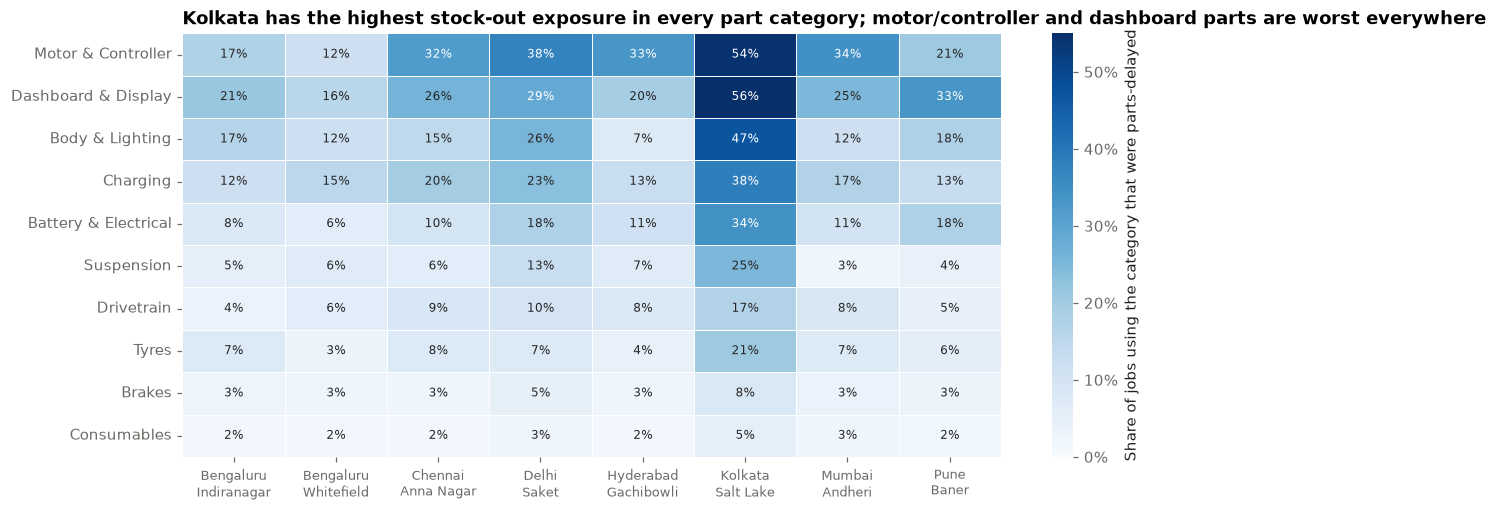

,jobs,delay_rate,supplier_lead_days
part_category,,,
Dashboard & Display,437,0.279,9.073
Motor & Controller,313,0.275,10.358
Body & Lighting,528,0.182,6.670
Charging,518,0.178,6.737
Battery & Electrical,1482,0.129,7.443
Suspension,574,0.080,5.406
Drivetrain,839,0.079,6.042
Tyres,1374,0.077,3.728
Brakes,9913,0.037,2.468


In [24]:
pc = pd.DataFrame(M["parts_delay_category_centre"]).set_index("part_category")
pc = pc.loc[pc.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pc, cmap="Blues", annot=True, fmt=".0%", annot_kws={"size": 8}, linewidths=0.5, vmin=0, vmax=0.55,
            cbar_kws={"label": "Share of jobs using the category that were parts-delayed", "format": pctfmt}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([t.get_text().replace(" - ", "\n") for t in ax.get_xticklabels()], rotation=0, fontsize=8.5)
ax.set_title("Kolkata has the highest stock-out exposure in every part category; motor/controller and dashboard parts are worst everywhere")
save(fig, "fig11_parts_delay_category_by_centre")
plt.show()
display(pd.DataFrame(M["parts_delay_by_category"]).set_index("part_category"))

In [25]:
k = fs[fs["center_id"] == "C008"]
print(f"Kolkata parts-delay rate {k['parts_delay_flag'].mean():.1%} vs network excl. Kolkata {fs.loc[fs['center_id'] != 'C008', 'parts_delay_flag'].mean():.1%}")
print(f"Kolkata mean turnaround {k['turnaround_hours'].mean():.1f} h vs median {k['turnaround_hours'].median():.2f} h")
print(f"Kolkata delayed jobs: mean parts wait {k.loc[k['parts_delay_flag'], 'parts_wait_hours'].mean():.0f} h")
ct = pd.crosstab(fs["center_id"].eq("C008"), fs["parts_delay_flag"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square Kolkata vs rest × parts delay: χ²={chi2:.0f}, p={p:.1e}, Cramér's V={np.sqrt(chi2 / ct.to_numpy().sum()):.2f}")

Kolkata parts-delay rate 11.2% vs network excl. Kolkata 4.1%
Kolkata mean turnaround 18.7 h vs median 2.34 h
Kolkata delayed jobs: mean parts wait 131 h
Chi-square Kolkata vs rest × parts delay: χ²=220, p=7.3e-50, Cramér's V=0.10


**Interpretation.** Parts delays are driven by **category** (motor & controller and dashboard/display parts are
delayed on ~27-28% of the jobs that need them; consumables on 2%) and by **location** (Kolkata's rate is 2-3×
other centres in almost every category, and Delhi is second). Because the data records the delay at job level -
not which part was short - the category view is an association; confirming it needs line-level stock-out records.
The pattern is consistent with Kolkata being furthest from the parts supply chain.

## 12. Technician skill, rework and overruns

,jobs,complex_share,qc_first_pass,comeback,duration_var_h,overrun,on_time,csat,margin
skill_level,,,,,,,,,
Junior,6323,0.050,0.906,0.055,0.648,0.557,0.656,3.954,0.293
Mid,6052,0.106,0.925,0.048,0.344,0.369,0.707,3.959,0.260
Senior,9526,0.147,0.948,0.037,0.139,0.275,0.786,4.091,0.224
Master,2119,0.192,0.961,0.043,-0.021,0.214,0.787,4.070,0.184


Complex jobs only (controls for job mix):


,jobs,qc_first_pass,comeback,duration_var_h,overrun,on_time,csat
skill_level,,,,,,,
Junior,315,0.873,0.057,1.090,0.419,0.416,3.598
Mid,640,0.895,0.080,0.686,0.341,0.500,3.565
Senior,1400,0.924,0.066,0.253,0.295,0.618,3.826
Master,407,0.946,0.076,0.002,0.263,0.627,3.880


saved reports/figures/fig12_skill_quality_and_overruns.png


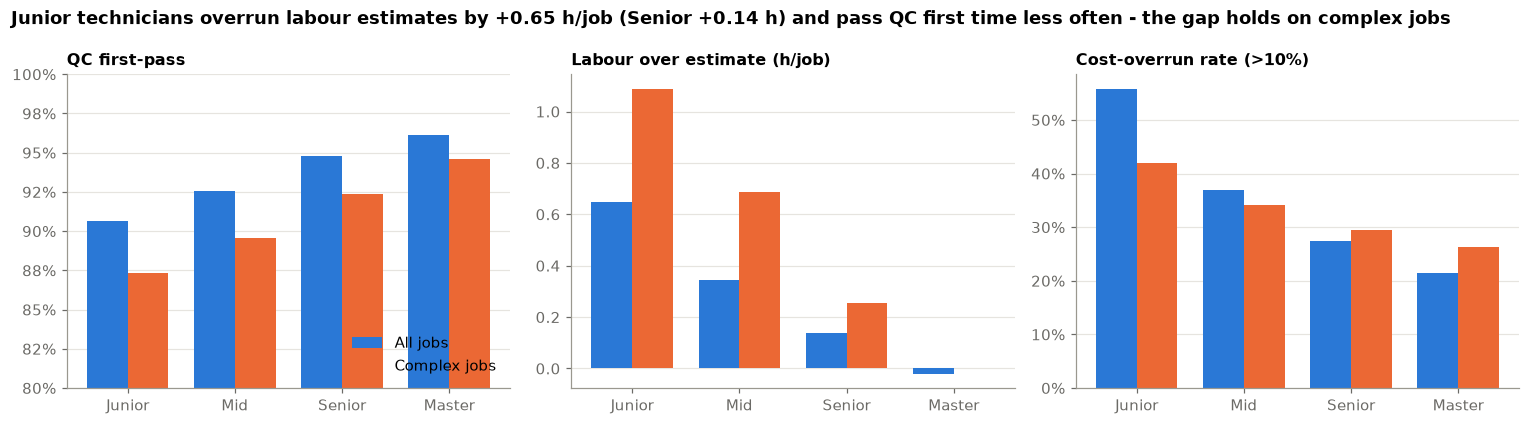

QC first-pass × skill: Cramér's V=0.08 (small); cost overrun × skill: Cramér's V=0.25 (moderate)
Zero-revenue rework visits: 893 jobs, ₹13.20 lakh cost, 1,177 labour hours


In [26]:
sk = pd.DataFrame(M["skill_profile"]).set_index("skill_level")
skc = pd.DataFrame(M["skill_profile_complex_jobs"]).set_index("skill_level")
display(sk[["jobs", "complex_share", "qc_first_pass", "comeback", "duration_var_h", "overrun", "on_time", "csat", "margin"]])
print("Complex jobs only (controls for job mix):")
display(skc[["jobs", "qc_first_pass", "comeback", "duration_var_h", "overrun", "on_time", "csat"]])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
xs = np.arange(4)
for ax, col, title, fmt in [(axes[0], "qc_first_pass", "QC first-pass", pctfmt), (axes[1], "duration_var_h", "Labour over estimate (h/job)", None),
                            (axes[2], "overrun", "Cost-overrun rate (>10%)", pctfmt)]:
    ax.bar(xs - 0.19, sk[col], width=0.38, color=BLUE, label="All jobs")
    ax.bar(xs + 0.19, skc[col], width=0.38, color=ORANGE, label="Complex jobs")
    ax.set_xticks(xs, sk.index)
    ax.set_title(title, fontsize=10.5)
    ax.grid(axis="x", visible=False)
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
axes[0].set_ylim(0.8, 1.0)
axes[0].legend(loc="lower right")
fig.suptitle(f"Junior technicians overrun labour estimates by {sk.loc['Junior', 'duration_var_h']:+.2f} h/job (Senior {sk.loc['Senior', 'duration_var_h']:+.2f} h) "
             f"and pass QC first time less often - the gap holds on complex jobs", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig12_skill_quality_and_overruns")
plt.show()
q, o = T["chi2_qc_vs_skill"], T["chi2_overrun_vs_skill"]
print(f"QC first-pass × skill: Cramér's V={q['cramers_v']:.2f} (small); cost overrun × skill: Cramér's V={o['cramers_v']:.2f} (moderate)")
rw = M["rework"]
print(f"Zero-revenue rework visits: {rw['rework_jobs']:,} jobs, {am.inr(rw['rework_cost'])} cost, {rw['rework_labour_hours']:,.0f} labour hours")

**Interpretation.** Skill is associated with **efficiency and first-time quality** more than with comebacks:
* Junior technicians take **+0.65 h per job** longer than estimated (Senior +0.14 h); on complex jobs +1.09 h.
  That excess is hidden capacity loss - across ~356 junior jobs/month it is roughly 0.6 of a technician.
* Juniors overrun the cost estimate on 56% of jobs vs 27% for Seniors (Cramér's V 0.25).
* QC first-pass is 90.6% for juniors vs 94.8% for seniors (small effect).
* Comeback rates by skill are close once job mix is controlled (complex jobs: Junior 5.7%, Senior 6.6%), so
  **we do not claim skill drives comebacks**.

Mumbai's roster (one Junior, one Mid, no Senior) and Delhi's Junior carrying 59% of that centre's jobs put this
skill effect exactly where capacity is already tight.

## 13. Cancellations and booking lead time

saved reports/figures/fig13_cancellation_lead_time.png


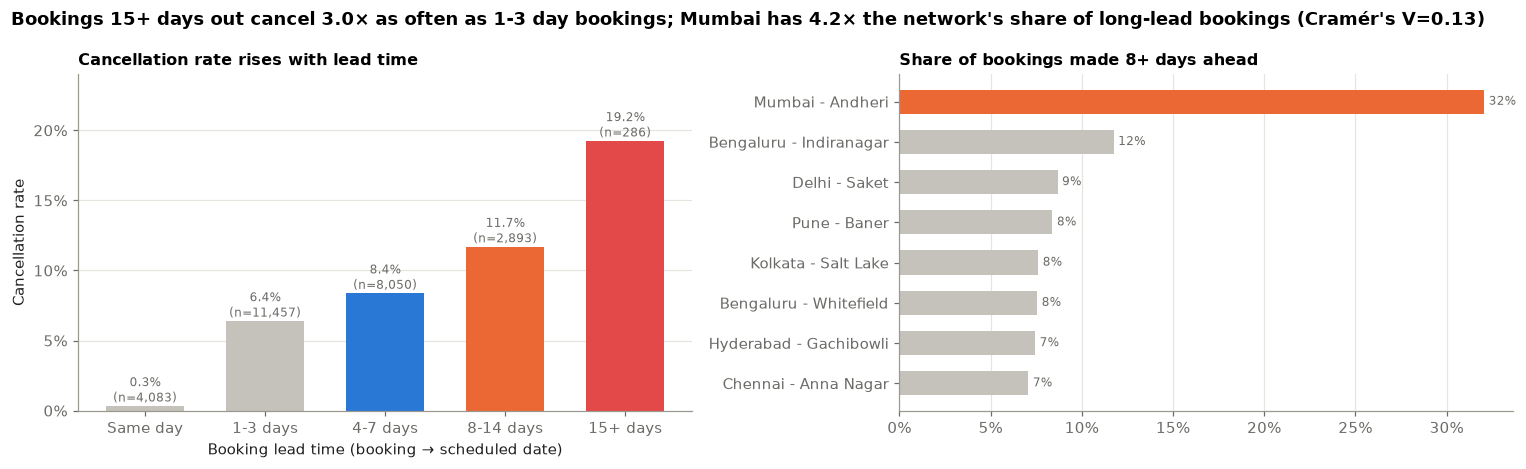

In [27]:
cl = pd.DataFrame(M["cancellation_by_lead_band"]).set_index("lead_time_band")
mixc = pd.DataFrame(M["lead_band_mix_by_centre"]).set_index("center_id")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].bar(cl.index, cl["cancellation_rate"], color=[GREY, GREY, BLUE, ORANGE, RED], width=0.65)
for i, (v, n) in enumerate(zip(cl["cancellation_rate"], cl["appointments"])):
    axes[0].annotate(f"{v:.1%}\n(n={n:,})", (i, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8, color=MUTED)
axes[0].yaxis.set_major_formatter(pctfmt)
axes[0].set_ylim(0, 0.24)
axes[0].set_xlabel("Booking lead time (booking → scheduled date)")
axes[0].set_ylabel("Cancellation rate")
axes[0].set_title("Cancellation rate rises with lead time", fontsize=10.5)
axes[0].grid(axis="x", visible=False)
long = (mixc["8-14 days"] + mixc["15+ days"]).sort_values()
axes[1].barh([NAMES[c] for c in long.index], long, color=[ORANGE if c == "C006" else GREY for c in long.index], height=0.6)
for i, v in enumerate(long):
    axes[1].annotate(f"{v:.0%}", (v, i), xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=MUTED)
axes[1].xaxis.set_major_formatter(pctfmt)
axes[1].set_title("Share of bookings made 8+ days ahead", fontsize=10.5)
axes[1].grid(axis="y", visible=False)
c = T["chi2_cancellation_vs_lead_band"]
fig.suptitle(f"Bookings 15+ days out cancel {cl.loc['15+ days', 'cancellation_rate'] / cl.loc['1-3 days', 'cancellation_rate']:.1f}× as often as 1-3 day bookings; "
             f"Mumbai has {long['C006'] / long.drop('C006').median():.1f}× the network's share of long-lead bookings (Cramér's V={c['cramers_v']:.2f})",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig13_cancellation_lead_time")
plt.show()

In [28]:
reasons = pd.DataFrame(M["cancellation_reasons_by_centre"]).set_index("center_id")
reasons.index = reasons.index.map(NAMES)
reasons["total"] = reasons.sum(axis=1)
reasons["long_wait_share"] = reasons["Long Wait for Slot"] / reasons["total"]
display(reasons.sort_values("long_wait_share", ascending=False))
display(pd.DataFrame(M["cancellation_by_channel"]).set_index("booking_channel"))
display(pd.DataFrame(M["cancellation_by_service_type"]).set_index("requested_service_type").sort_values("cancellation_rate", ascending=False).head(4))
wd_c = wd[["appointments", "cancellation_rate"]]
wd_c

,Customer Rescheduled,Issue Resolved via OTA Update,Long Wait for Slot,Personal Reasons,Price Concern,Visited Another Workshop,total,long_wait_share
center_id,,,,,,,,
Mumbai - Andheri,97,5,95,43,44,42,326,0.291
Bengaluru - Indiranagar,70,15,86,56,45,54,326,0.264
Delhi - Saket,48,5,47,28,37,28,193,0.244
Kolkata - Salt Lake,38,9,34,24,22,22,149,0.228
Pune - Baner,45,9,31,26,9,23,143,0.217
Chennai - Anna Nagar,76,9,46,36,35,39,241,0.191
Bengaluru - Whitefield,76,13,51,50,40,41,271,0.188
Hyderabad - Gachibowli,50,13,30,25,18,25,161,0.186


,appointments,cancellation_rate,no_show_rate,mean_lead_days
booking_channel,,,,
Ather App,14763,0.078,0.038,3.971
Call Centre,5713,0.080,0.035,4.868
Walk-in,3763,0.000,0.000,0.000
Website,2530,0.082,0.044,4.487


,appointments,cancellation_rate,no_show_rate,mean_lead_days
requested_service_type,,,,
Software Update Support,1073,0.107,0.031,3.521
Electrical Diagnostics,1248,0.074,0.030,3.635
Tyre Replacement,1554,0.071,0.032,3.741
Charging System Repair,744,0.069,0.034,3.605


,appointments,cancellation_rate
weekday,,
Monday,4475,0.089
Tuesday,3967,0.067
Wednesday,3850,0.068
Thursday,3948,0.062
Friday,4217,0.057
Saturday,6312,0.063


**Interpretation.**
* Lead time is the main booking-side correlate of cancellation: same-day/walk-in bookings almost never cancel,
  1-3 day bookings cancel 6.4%, 8-14 day 11.7% and 15+ day 19.2%. The effect size is small-moderate
  (Cramér's V 0.13) - most cancellations are still personal or rescheduling reasons.
* **Mumbai** books ~32% of appointments 8+ days ahead (network ~12%), has the highest cancellation rate (8.6%),
  and "Long Wait for Slot" accounts for ~29% of its cancellations - the highest share in the network. This is consistent with slot scarcity
  pushing customers out, which links back to the capacity bottleneck.
* Monday cancellations (8.9%) are ~2.5 points above other weekdays - a reminder/confirmation gap is a plausible
  hypothesis (Monday slots are booked before the weekend).
* Software-update appointments cancel most (10.7%), largely "Issue resolved via OTA update" - a *good*
  cancellation that frees capacity if the slot is released quickly.

## 14. Cost overruns

In [29]:
ov = pd.DataFrame(M["overrun_drivers"]).set_index("additional_work_found")
display(ov)
ov_c = fs.groupby(["center_name", "additional_work_found"])["cost_overrun_flag"].mean().unstack()
ov_c.columns = ["no extra work", "extra work found"]
ov_c.sort_values("no extra work", ascending=False)

,jobs,overrun,cost_var_pct_median,revenue,csat,margin,share_of_jobs
additional_work_found,,,,,,,
False,20009,0.248,0.024,"54,491,508.850",4.098,0.263,0.831
True,4083,0.953,0.709,"23,747,154.530",3.654,0.202,0.169


,no extra work,extra work found
center_name,,
Mumbai - Andheri,0.379,0.957
Delhi - Saket,0.318,0.948
Bengaluru - Indiranagar,0.278,0.952
Bengaluru - Whitefield,0.259,0.954
Hyderabad - Gachibowli,0.207,0.960
Chennai - Anna Nagar,0.206,0.961
Kolkata - Salt Lake,0.133,0.946
Pune - Baner,0.095,0.935


**Interpretation.** 17% of jobs uncover additional work during service; 95% of those exceed the estimate by >10%
(median +71%) and their customers rate 3.65 vs 4.10. Without additional work the overrun rate is 25%, and it is
highest at Mumbai and Delhi - the junior-heavy, overloaded centres - consistent with labour overruns. The
estimate is therefore weak at two points: **scope discovered after the quote** (an inspection/approval process
gap) and **labour time** (a skill/capacity gap).

## 15. Bottleneck identification

Bringing the evidence together. A *bottleneck* here is a stage or resource where work queues or fails, measurably
worse than the network benchmark, and associated with the outcome metrics management cares about.

In [30]:
best = cs.loc[["C004", "C005"]]
bott = pd.DataFrame([
    ("B1 Technician capacity (Mumbai, Chennai, Delhi)", "Service / technician time",
     f"Utilisation 2026: Mumbai {cs.loc['C006','utilisation_2026']:.0%}, Chennai {cs.loc['C003','utilisation_2026']:.0%}, Delhi {cs.loc['C007','utilisation_2026']:.0%}",
     f"Pune {cs.loc['C005','utilisation_2026']:.0%}, Hyderabad {cs.loc['C004','utilisation_2026']:.0%}",
     f"On-time {cs.loc['C006','on_time']:.0%}/{cs.loc['C003','on_time']:.0%}/{cs.loc['C007','on_time']:.0%} vs {best['on_time'].mean():.0%}; load>100% → on-time ≤61%"),
    ("B2 Saturday peak queue", "Check-in → service start",
     f"Saturday wait {wd.loc['Saturday','wait_h']:.2f} h, on-time {wd.loc['Saturday','on_time']:.0%}, {wd.loc['Saturday','job_share']:.0%} of jobs",
     f"Tue-Thu wait {wd.loc[['Tuesday','Wednesday','Thursday'],'wait_h'].mean():.2f} h, on-time {wd.loc[['Tuesday','Wednesday','Thursday'],'on_time'].mean():.0%}",
     f"Cramér's V {T['chi2_on_time_saturday_vs_weekday']['cramers_v']:.2f}; Saturday CSAT {wd.loc['Saturday','csat']:.2f}"),
    ("B3 Parts availability (Kolkata; motor/controller & dashboard parts)", "Parts allocation",
     f"Kolkata parts-delay {cs.loc['C008','parts_delay']:.1%}; motor/controller {pd.DataFrame(M['parts_delay_by_category']).set_index('part_category').loc['Motor & Controller','delay_rate']:.0%} of jobs",
     f"Bengaluru-Whitefield {cs.loc['C002','parts_delay']:.1%}; network {H['parts_delay_rate']:.1%}",
     f"Delayed jobs 0% on-time, median TAT {pdi.loc[True,'tat_median_h']:.0f} h, CSAT {pdi.loc[True,'csat']:.2f}"),
    ("B4 Skill mix → labour overruns & first-time quality", "Service + quality check",
     f"Junior: +{sk.loc['Junior','duration_var_h']:.2f} h/job, QC {sk.loc['Junior','qc_first_pass']:.1%}, overrun {sk.loc['Junior','overrun']:.0%}",
     f"Senior: +{sk.loc['Senior','duration_var_h']:.2f} h/job, QC {sk.loc['Senior','qc_first_pass']:.1%}, overrun {sk.loc['Senior','overrun']:.0%}",
     f"Mumbai has 0 Senior/Master techs; rework cost {am.inr(rw['rework_cost'])}"),
    ("B5 Booking lead time → cancellations (Mumbai)", "Appointment",
     f"Mumbai lead {cs.loc['C006','mean_lead_days']:.1f} days, cancellation {cs.loc['C006','cancellation_rate']:.1%}",
     f"Other centres lead {cs.drop('C006')['mean_lead_days'].median():.1f} days, cancellation {cs.drop('C006')['cancellation_rate'].median():.1%}",
     f"15+ day bookings cancel {cl.loc['15+ days','cancellation_rate']:.0%}"),
], columns=["Bottleneck", "Process stage", "Evidence (outlier)", "Benchmark", "Outcome association"])
bott

,Bottleneck,Process stage,Evidence (outlier),Benchmark,Outcome association
0,"B1 Technician capacity (Mumbai, Chennai, Delhi)",Service / technician time,"Utilisation 2026: Mumbai 125%, Chennai 119%, D...","Pune 65%, Hyderabad 76%",On-time 62%/65%/67% vs 82%; load>100% → on-tim...
1,B2 Saturday peak queue,Check-in → service start,"Saturday wait 3.06 h, on-time 55%, 24% of jobs","Tue-Thu wait 0.56 h, on-time 80%",Cramér's V 0.23; Saturday CSAT 3.78
2,B3 Parts availability (Kolkata; motor/controll...,Parts allocation,Kolkata parts-delay 11.2%; motor/controller 27...,Bengaluru-Whitefield 3.1%; network 4.7%,"Delayed jobs 0% on-time, median TAT 116 h, CSA..."
3,B4 Skill mix → labour overruns & first-time qu...,Service + quality check,"Junior: +0.65 h/job, QC 90.6%, overrun 56%","Senior: +0.14 h/job, QC 94.8%, overrun 27%",Mumbai has 0 Senior/Master techs; rework cost ...
4,B5 Booking lead time → cancellations (Mumbai),Appointment,"Mumbai lead 6.0 days, cancellation 8.6%","Other centres lead 3.1 days, cancellation 6.4%",15+ day bookings cancel 19%


## 16. What-if analysis and parts ABC (optional enhancements, spec §20)

### 16.1 Adding one technician at the overloaded centres

**Model (simple and stated):** demand fixed at the centre's 2026 jobs; each day's load ratio is scaled by
n/(n+1); the change in on-time is read off the *network* on-time-by-load curve (§9.2) as a delta, so each centre
keeps its own residual gap (skill mix, parts). No recovered cancellations or growth are credited. This is a
planning estimate, not a forecast.

,technicians_now,technicians_new,jobs_per_month,utilisation_now,utilisation_projected,overloaded_day_share_now,overloaded_day_share_projected,on_time_now,on_time_projected,on_time_delta_pts,extra_on_time_jobs_per_month
center_id,,,,,,,,,,,
Mumbai - Andheri,2,3,190.556,1.246,0.830,0.380,0.145,0.545,0.742,0.197,37.512
Chennai - Anna Nagar,2,3,198.111,1.185,0.790,0.487,0.141,0.568,0.806,0.239,47.326
Delhi - Saket,2,3,164.222,1.015,0.677,0.292,0.077,0.594,0.778,0.184,30.194


saved reports/figures/fig14_what_if_add_technician.png


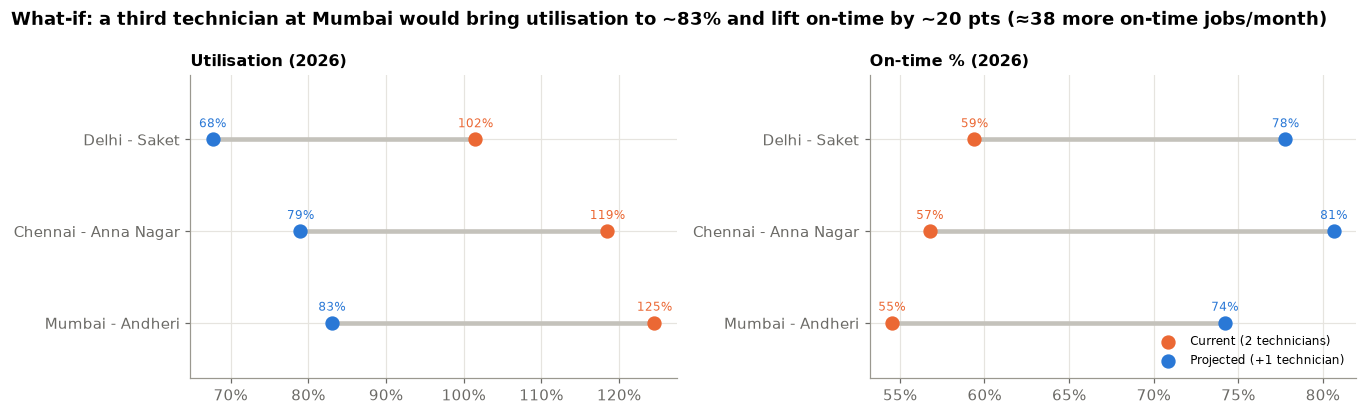

Payroll cost of one technician (assumption: hourly cost × 8 h × mean working days): Mid ₹58,347/month, Senior ₹75,017/month
Mumbai context: {'profit_per_month_2026': 159734.359, 'revenue_per_month_2026': 580815.403, 'jobs_jan_sep_2025': 1147, 'jobs_jan_sep_2026': 1715, 'jobs_yoy_growth': 0.495, 'hire_cost_share_of_profit': 0.47}


In [31]:
I = M["impact"]
wi = pd.DataFrame([I["what_if_C006_plus1"], I["what_if_C003_plus1"], I["what_if_C007_plus1"]]).set_index("center_id")
wi.index = wi.index.map(NAMES)
display(wi)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
y = np.arange(len(wi))
for ax, (now, proj, title, fmt) in zip(axes, [("utilisation_now", "utilisation_projected", "Utilisation (2026)", pctfmt),
                                               ("on_time_now", "on_time_projected", "On-time % (2026)", pctfmt)]):
    ax.hlines(y, wi[now], wi[proj], color=GREY, lw=3)
    ax.scatter(wi[now], y, color=ORANGE, s=70, zorder=3, label="Current (2 technicians)")
    ax.scatter(wi[proj], y, color=BLUE, s=70, zorder=3, label="Projected (+1 technician)")
    for i, (a, b) in enumerate(zip(wi[now], wi[proj])):
        ax.annotate(f"{a:.0%}", (a, i), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color=ORANGE)
        ax.annotate(f"{b:.0%}", (b, i), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color=BLUE)
    ax.set_yticks(y, wi.index)
    ax.xaxis.set_major_formatter(fmt)
    ax.set_title(title, fontsize=10.5)
    ax.set_ylim(-0.6, len(wi) - 0.3)
axes[1].legend(loc="lower right", fontsize=8)
w6 = I["what_if_C006_plus1"]
fig.suptitle(f"What-if: a third technician at Mumbai would bring utilisation to ~{w6['utilisation_projected']:.0%} and lift on-time by "
             f"~{w6['on_time_delta_pts'] * 100:.0f} pts (≈{w6['extra_on_time_jobs_per_month']:.0f} more on-time jobs/month)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "fig14_what_if_add_technician")
plt.show()
print(f"Payroll cost of one technician (assumption: hourly cost × 8 h × mean working days): Mid {am.inr(I['technician_monthly_cost_mid'])}/month, "
      f"Senior {am.inr(I['technician_monthly_cost_senior'])}/month")
print("Mumbai context:", {k: round(v, 3) if isinstance(v, float) else v for k, v in I["mumbai_context"].items()})

### 16.2 Saturday options

In [32]:
sat = pd.DataFrame({"Shift 15% of booked Saturday hours to Tue-Thu": I["what_if_saturday_shift_15pct"],
                    "+2 h Saturday shift at the 4 loaded centres": I["what_if_saturday_overtime_hot_centres"]})
sat

,Shift 15% of booked Saturday hours to Tue-Thu,+2 h Saturday shift at the 4 loaded centres
shift_share_of_booked_saturday_hours,0.150,NaN
saturday_on_time_now,0.452,0.367
saturday_on_time_projected,0.538,0.527
tue_thu_on_time_now,0.754,NaN
tue_thu_on_time_projected,0.729,NaN
network_on_time_now,0.671,NaN
network_on_time_projected,0.680,NaN
extra_on_time_jobs_per_month,12.769,30.420
booked_share_of_saturday_hours,0.838,NaN
centres,NaN,"C001,C003,C006,C007"


Shifting bookings alone helps Saturday (+9 pts on-time) but pushes Tue-Thu into the overload zone at already busy
centres, so the *network* gain is small (~13 extra on-time jobs/month). Adding Saturday capacity at the four loaded
centres lifts Saturday on-time there by ~16 pts (~30 jobs/month) at an estimated ₹0.46 lakh/month overtime cost.
The two levers are complementary; capacity has to come first where the weekdays are also saturated.

### 16.3 ABC analysis of parts consumption

saved reports/figures/fig15_parts_abc_pareto.png


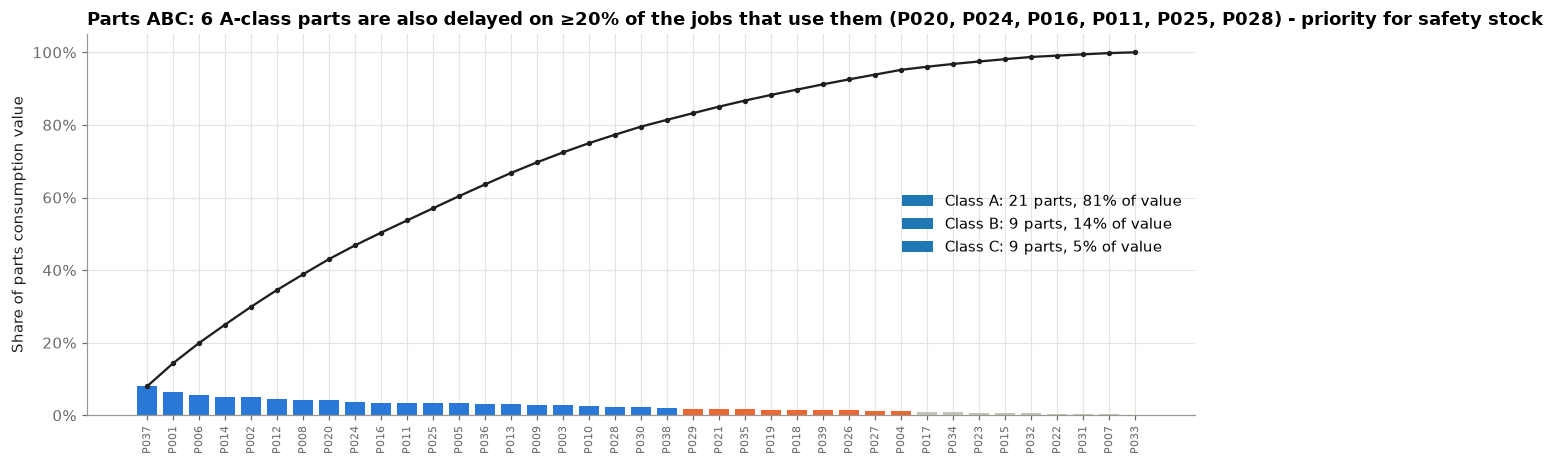

,part_id,part_name,part_category,unit_cost,supplier_lead_days,units,value_share,cum_share,delay_rate,abc_class
0,P037,Service Consumables Kit,Consumables,250,1,13825,0.080,0.080,0.024,A
1,P001,Brake Pad Set - Front,Brakes,650,3,4223,0.064,0.144,0.045,A
2,P006,Rear Tyre 12-inch,Tyres,2100,4,1146,0.056,0.200,0.079,A
3,P014,Battery Cell Module,Battery & Electrical,18500,14,118,0.051,0.250,0.110,A
4,P002,Brake Pad Set - Rear,Brakes,600,3,3537,0.049,0.299,0.048,A
5,P012,Main Wiring Harness,Battery & Electrical,4200,9,475,0.046,0.346,0.135,A
6,P008,Drive Belt,Drivetrain,2300,6,808,0.043,0.389,0.080,A
7,P020,Motor Controller - 450 Series,Motor & Controller,14500,12,125,0.042,0.431,0.296,A
8,P024,Motor Assembly,Motor & Controller,32000,18,51,0.038,0.468,0.333,A
9,P016,Portable Charger,Charging,6500,7,232,0.035,0.503,0.246,A


Kolkata safety-stock estimate (parts with ≥10% delay rate, one supplier lead time of 2026 demand): 34 SKUs, ₹1.77 lakh one-off working capital


,part_id,part_name,part_category,unit_cost,supplier_lead_days,units,delay_rate,jobs,monthly_units,cover_units,stock_value
0,P024,Motor Assembly,Motor & Controller,32000,18,4,0.500,4,0.444,1,32000
1,P014,Battery Cell Module,Battery & Electrical,18500,14,3,0.667,3,0.333,1,18500
2,P020,Motor Controller - 450 Series,Motor & Controller,14500,12,5,0.400,5,0.556,1,14500
3,P021,Motor Controller - Rizta,Motor & Controller,13200,12,2,0.500,2,0.222,1,13200
4,P026,Dashboard Display - Rizta,Dashboard & Display,9800,12,5,0.400,5,0.556,1,9800
5,P013,Battery Management System Board,Battery & Electrical,9800,10,4,0.500,4,0.444,1,9800
6,P019,Onboard Charger Module,Charging,7800,12,2,1.000,2,0.222,1,7800
7,P036,Front Fork Assembly,Suspension,7200,10,11,0.545,11,1.222,1,7200
8,P016,Portable Charger,Charging,6500,7,8,0.500,8,0.889,1,6500
9,P011,DC-DC Converter,Battery & Electrical,5500,8,12,0.333,12,1.333,1,5500


In [33]:
abc = am.abc_parts(lines)
fig, ax = plt.subplots(figsize=(13, 4.5))
cols = {"A": BLUE, "B": ORANGE, "C": GREY}
ax.bar(range(len(abc)), abc["value_share"], color=abc["abc_class"].map(cols), width=0.75)
ax.plot(range(len(abc)), abc["cum_share"], color=INK, lw=1.5, marker="o", ms=2.5)
for cls in "ABC":
    ax.bar([], [], color=cols[cls], label=f"Class {cls}: {int((abc['abc_class'] == cls).sum())} parts, {abc.loc[abc['abc_class'] == cls, 'value_share'].sum():.0%} of value")
ax.set_xticks(range(len(abc)), abc["part_id"], rotation=90, fontsize=7.5)
ax.yaxis.set_major_formatter(pctfmt)
ax.set_ylabel("Share of parts consumption value")
ax.legend(loc="center right")
hi = abc[(abc["abc_class"] == "A") & (abc["delay_rate"] >= 0.2)]
ax.set_title(f"Parts ABC: {len(hi)} A-class parts are also delayed on ≥20% of the jobs that use them ({', '.join(hi['part_id'])}) - priority for safety stock")
save(fig, "fig15_parts_abc_pareto")
plt.show()
display(abc.head(21)[["part_id", "part_name", "part_category", "unit_cost", "supplier_lead_days", "units", "value_share", "cum_share", "delay_rate", "abc_class"]])
ss = am.safety_stock_estimate(lines, "C008")
print(f"Kolkata safety-stock estimate (parts with ≥10% delay rate, one supplier lead time of 2026 demand): "
      f"{len(ss)} SKUs, {am.inr(ss['stock_value'].sum())} one-off working capital")
ss.head(10)

## 17. Evidence metrics used in the documents

`src/analysis_metrics.py` computes every figure cited in `docs/`. Running it here regenerates
`reports/analysis_metrics.json`.

In [34]:
am.main()

NETWORK HEADLINE KPIs (Jan 2025 - Sep 2026)
Work orders 24,092 | Appointments 26,769
Revenue ₹7.82 crore | Cost ₹5.91 crore | Profit ₹1.91 crore | Margin 24.4%
On-time 73.2% | Turnaround mean 11.2 h / median 2.57 h | Wait 1.20 h
Utilisation 75.6% | Cancellation 6.8% | CSAT 4.02 (74.5% >=4)
Overrun rate 36.7% | Parts delay 4.7% | QC first-pass 93.2% | Comeback 4.5% | Repeat-visit 85.7%

CENTRE SCORECARD
                       center_name  jobs  on_time  wait_h  tat_mean_h  parts_delay  utilisation  utilisation_2026  overloaded_day_share_2026  cancellation_rate  mean_lead_days  qc_first_pass  comeback  overrun  csat  margin
center_id                                                                                                                                                                                                                      
C001       Bengaluru - Indiranagar  4117    0.753   0.857       9.321        0.036        0.804             0.949                      0.231      

## 18. Conclusions and hand-off to the documents

| # | Bottleneck | Strongest evidence | Confidence |
|---|---|---|---|
| B1 | Technician capacity at Mumbai, Chennai, Delhi | 102-125% utilisation in 2026; on-time falls from ~89% to ≤61% once daily load > 100% (centre-day ρ≈−0.56) | High (consistent across centres, months and days) |
| B2 | Saturday peak queue | 24% of jobs, 3.1 h mean wait, 55% on-time | High |
| B3 | Parts availability at Kolkata and for motor/controller & dashboard parts | 11.2% vs 3-4% parts-delay; delayed jobs 0% on-time, CSAT 2.95 | High for the effect, medium for the category attribution (job-level data) |
| B4 | Skill mix → labour overruns and first-pass quality | Junior +0.65 h/job vs +0.14 h; overrun 56% vs 27% | Medium (assignment is not random: juniors get simpler jobs) |
| B5 | Long booking lead time → cancellations at Mumbai | 6.0-day mean lead; 8.6% cancellation; 15+ day bookings cancel 19% | Medium (effect size small-moderate) |

Each is written up with metric evidence in `docs/findings.md`, investigated with 5 Whys / fishbone in
`docs/root_cause_analysis.md`, placed on the workflow in `docs/process_map.md`, and turned into prioritised, measurable
actions in `docs/recommendations.md`. None of these associations is treated as proven cause: each recommendation
names the operational data that would confirm or reject its hypothesis.